# EDA - Formula 1 World Championship

Este notebook realiza el análisis exploratorio inicial del dataset de Formula 1.

La unidad de análisis elegida es **piloto-carrera**, es decir, cada fila representa la participación de un piloto en una carrera específica.

Tablas utilizadas:

- `results.csv`
- `races.csv`
- `drivers.csv`
- `constructors.csv`
- `status.csv`
- `driver_standings.csv`
- `circuits.csv`

No se utiliza `qualifying.csv` en esta primera versión porque tiene muchos valores faltantes, especialmente en Q2 y Q3, y además el formato de clasificación cambió mucho a lo largo de la historia de la F1.

El objetivo del EDA es:

1. Integrar las tablas necesarias mediante joins.
2. Limpiar y transformar variables.
3. Entender la estructura de la base final.
4. Analizar valores faltantes, distribuciones y relaciones entre variables.
5. Generar una base procesada para usar luego en PCA y clustering.

In [1]:
# ============================================================
# 1) IMPORTS Y CONFIGURACIÓN GENERAL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

MOSTRAR_GRAFICOS = True

# ------------------------------------------------------------
# Detectar carpeta raíz del proyecto
# ------------------------------------------------------------

def encontrar_raiz_proyecto():
    """
    Busca hacia arriba una carpeta que contenga data/raw.
    Esto permite ejecutar el notebook desde notebooks/eda o desde la raíz.
    """
    actual = Path.cwd()
    
    for carpeta in [actual] + list(actual.parents):
        if (carpeta / "data" / "raw").exists():
            return carpeta
    
    raise FileNotFoundError(
        "No se encontró la carpeta data/raw. "
        "Revisá que estés dentro del proyecto Analisis-multivariado."
    )

BASE_DIR = encontrar_raiz_proyecto()
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
REPORTS_DIR = BASE_DIR / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Carpeta raíz del proyecto:", BASE_DIR)
print("Carpeta de datos raw:", DATA_RAW)
print("Carpeta de salida:", DATA_PROCESSED)

Carpeta raíz del proyecto: /Users/santinoalmiron/Documents/Facultad/3º año/1º cuatrimestre/Analisis Multivariado/Analisis-multivariado
Carpeta de datos raw: /Users/santinoalmiron/Documents/Facultad/3º año/1º cuatrimestre/Analisis Multivariado/Analisis-multivariado/data/raw
Carpeta de salida: /Users/santinoalmiron/Documents/Facultad/3º año/1º cuatrimestre/Analisis Multivariado/Analisis-multivariado/data/processed


## 1. Carga de datos

En esta sección se cargan únicamente las tablas seleccionadas para el análisis.

La base original está separada en varias tablas relacionales. Por eso, antes de analizar, necesitamos unir la información de carreras, pilotos, escuderías, circuitos, resultados y estado final de cada participación.

In [2]:
# ============================================================
# 2) CARGA DE TABLAS
# ============================================================

archivos = {
    "results": "results.csv",
    "races": "races.csv",
    "drivers": "drivers.csv",
    "constructors": "constructors.csv",
    "status": "status.csv",
    "driver_standings": "driver_standings.csv",
    "circuits": "circuits.csv"
}

tablas = {}

for nombre, archivo in archivos.items():
    path = DATA_RAW / archivo
    
    if not path.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {path}")
    
    df = pd.read_csv(path)
    
    # En Ergast/F1 muchos faltantes aparecen como \N
    df = df.replace("\\N", np.nan)
    
    tablas[nombre] = df
    
    print(f"{nombre}: {df.shape[0]} filas, {df.shape[1]} columnas")

results = tablas["results"]
races = tablas["races"]
drivers = tablas["drivers"]
constructors = tablas["constructors"]
status = tablas["status"]
driver_standings = tablas["driver_standings"]
circuits = tablas["circuits"]

results: 26759 filas, 18 columnas
races: 1125 filas, 18 columnas
drivers: 861 filas, 9 columnas
constructors: 212 filas, 5 columnas
status: 139 filas, 2 columnas
driver_standings: 34863 filas, 7 columnas
circuits: 77 filas, 9 columnas


In [3]:
# ============================================================
# 3) INSPECCIÓN INICIAL DE CADA TABLA
# ============================================================

for nombre, df in tablas.items():
    print("\n" + "=" * 80)
    print(nombre.upper())
    print("=" * 80)
    display(df.head())
    print(df.info())


RESULTS


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number           26753 non-null  object 
 5   grid             26759 non-null  int64  
 6   position         15806 non-null  object 
 7   positionText     26759 non-null  object 
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time             7680 non-null   object 
 12  milliseconds     7680 non-null   object 
 13  fastestLap       8252 non-null   object 
 14  rank             8510 non-null   object 
 15  fastestLapTime   8252 non-null   object 
 16  fastestLapSpeed  8252 non-null   object 
 17  statusId    

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   raceId       1125 non-null   int64 
 1   year         1125 non-null   int64 
 2   round        1125 non-null   int64 
 3   circuitId    1125 non-null   int64 
 4   name         1125 non-null   object
 5   date         1125 non-null   object
 6   time         394 non-null    object
 7   url          1125 non-null   object
 8   fp1_date     90 non-null     object
 9   fp1_time     68 non-null     object
 10  fp2_date     90 non-null     object
 11  fp2_time     68 non-null     object
 12  fp3_date     72 non-null     object
 13  fp3_time     53 non-null     object
 14  quali_date   90 non-null     object
 15  quali_time   68 non-null     object
 16  sprint_date  18 non-null     object
 17  sprint_time  15 non-null     object
dtypes: int64(4), object(14)
memory usage: 158.3+ KB
None

DRIVERS


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   statusId  139 non-null    int64 
 1   status    139 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.3+ KB
None

DRIVER_STANDINGS


,driverStandingsId,raceId,driverId,points,position,positionText,wins
0,1,18,1,10.0,1,1,1
1,2,18,2,8.0,2,2,0
2,3,18,3,6.0,3,3,0
3,4,18,4,5.0,4,4,0
4,5,18,5,4.0,5,5,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34863 entries, 0 to 34862
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   driverStandingsId  34863 non-null  int64  
 1   raceId             34863 non-null  int64  
 2   driverId           34863 non-null  int64  
 3   points             34863 non-null  float64
 4   position           34863 non-null  int64  
 5   positionText       34863 non-null  object 
 6   wins               34863 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 1.9+ MB
None

CIRCUITS


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   circuitId   77 non-null     int64  
 1   circuitRef  77 non-null     object 
 2   name        77 non-null     object 
 3   location    77 non-null     object 
 4   country     77 non-null     object 
 5   lat         77 non-null     float64
 6   lng         77 non-null     float64
 7   alt         77 non-null     int64  
 8   url         77 non-null     object 
dtypes: float64(2), int64(2), object(5)
memory usage: 5.5+ KB
None


## 2. Preparación previa al join

Antes de unir las tablas, se convierten algunas columnas numéricas y de fecha al tipo correcto.

También se crean variables auxiliares, como el nombre completo del piloto.

In [4]:
# ============================================================
# 4) CONVERSIÓN DE TIPOS Y PREPARACIÓN PREVIA
# ============================================================

def convertir_a_numerico(df, columnas):
    for col in columnas:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

# results
results = convertir_a_numerico(
    results,
    [
        "resultId", "raceId", "driverId", "constructorId",
        "grid", "positionOrder", "points", "laps",
        "milliseconds", "fastestLap", "rank",
        "fastestLapSpeed", "statusId"
    ]
)

# races
races = convertir_a_numerico(
    races,
    ["raceId", "year", "round", "circuitId"]
)

races["date"] = pd.to_datetime(races["date"], errors="coerce")

# drivers
drivers = convertir_a_numerico(drivers, ["driverId"])
drivers["dob"] = pd.to_datetime(drivers["dob"], errors="coerce")

drivers["driver_name"] = (
    drivers["forename"].fillna("") + " " + drivers["surname"].fillna("")
).str.strip()

# constructors
constructors = convertir_a_numerico(constructors, ["constructorId"])

# status
status = convertir_a_numerico(status, ["statusId"])

# driver standings
driver_standings = convertir_a_numerico(
    driver_standings,
    ["driverStandingsId", "raceId", "driverId", "points", "position", "wins"]
)

# circuits
circuits = convertir_a_numerico(
    circuits,
    ["circuitId", "lat", "lng", "alt"]
)

print("Tipos convertidos correctamente.")

Tipos convertidos correctamente.


## 3. Integración de tablas mediante joins

La base final se arma tomando como tabla principal `results.csv`, porque contiene una fila por piloto en cada carrera.

Luego se agregan:

- Datos de la carrera desde `races.csv`.
- Datos del piloto desde `drivers.csv`.
- Datos de la escudería desde `constructors.csv`.
- Estado final de la carrera desde `status.csv`.
- Información del circuito desde `circuits.csv`.
- Posición y puntos acumulados del campeonato desde `driver_standings.csv`.

Importante: `driver_standings.csv` contiene información acumulada del campeonato luego de cada carrera. Sirve para análisis descriptivo, pero si más adelante se quisiera hacer un modelo predictivo, hay que tener cuidado porque puede introducir información posterior a la carrera.

In [5]:
# ============================================================
# 5) JOINS
# ============================================================

# Selección y renombrado de columnas para evitar conflictos
results_sel = results[
    [
        "resultId", "raceId", "driverId", "constructorId",
        "grid", "positionOrder", "points", "laps",
        "milliseconds", "fastestLap", "rank",
        "fastestLapTime", "fastestLapSpeed", "statusId"
    ]
].copy()

results_sel = results_sel.rename(columns={
    "points": "race_points",
    "rank": "fastest_lap_rank"
})

races_sel = races[
    ["raceId", "year", "round", "circuitId", "name", "date"]
].copy()

races_sel = races_sel.rename(columns={
    "name": "race_name",
    "date": "race_date"
})

drivers_sel = drivers[
    ["driverId", "driverRef", "driver_name", "dob", "nationality"]
].copy()

drivers_sel = drivers_sel.rename(columns={
    "nationality": "driver_nationality"
})

constructors_sel = constructors[
    ["constructorId", "constructorRef", "name", "nationality"]
].copy()

constructors_sel = constructors_sel.rename(columns={
    "name": "constructor_name",
    "nationality": "constructor_nationality"
})

status_sel = status[
    ["statusId", "status"]
].copy()

circuits_sel = circuits[
    ["circuitId", "circuitRef", "name", "location", "country", "lat", "lng", "alt"]
].copy()

circuits_sel = circuits_sel.rename(columns={
    "name": "circuit_name",
    "location": "circuit_location",
    "country": "circuit_country",
    "lat": "circuit_lat",
    "lng": "circuit_lng",
    "alt": "circuit_alt"
})

driver_standings_sel = driver_standings[
    ["raceId", "driverId", "points", "position", "wins"]
].copy()

driver_standings_sel = driver_standings_sel.rename(columns={
    "points": "driver_championship_points",
    "position": "driver_championship_position",
    "wins": "driver_championship_wins"
})

# ------------------------------------------------------------
# Join principal
# ------------------------------------------------------------

base = results_sel.copy()
print("Base inicial results:", base.shape)

base = base.merge(
    races_sel,
    on="raceId",
    how="left",
    validate="many_to_one"
)
print("Luego de unir races:", base.shape)

base = base.merge(
    drivers_sel,
    on="driverId",
    how="left",
    validate="many_to_one"
)
print("Luego de unir drivers:", base.shape)

base = base.merge(
    constructors_sel,
    on="constructorId",
    how="left",
    validate="many_to_one"
)
print("Luego de unir constructors:", base.shape)

base = base.merge(
    status_sel,
    on="statusId",
    how="left",
    validate="many_to_one"
)
print("Luego de unir status:", base.shape)

base = base.merge(
    circuits_sel,
    on="circuitId",
    how="left",
    validate="many_to_one"
)
print("Luego de unir circuits:", base.shape)

base = base.merge(
    driver_standings_sel,
    on=["raceId", "driverId"],
    how="left",
    validate="many_to_one"
)

print("Luego de unir driver_standings:", base.shape)

display(base.head())

Base inicial results: (26759, 14)
Luego de unir races: (26759, 19)
Luego de unir drivers: (26759, 23)
Luego de unir constructors: (26759, 26)
Luego de unir status: (26759, 27)
Luego de unir circuits: (26759, 34)
Luego de unir driver_standings: (26759, 37)


,resultId,raceId,driverId,constructorId,grid,positionOrder,race_points,laps,milliseconds,fastestLap,fastest_lap_rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,race_name,race_date,driverRef,driver_name,dob,driver_nationality,constructorRef,constructor_name,constructor_nationality,status,circuitRef,circuit_name,circuit_location,circuit_country,circuit_lat,circuit_lng,circuit_alt,driver_championship_points,driver_championship_position,driver_championship_wins
0,1,18,1,1,1,1,10.0,58,5690616.0,39.0,2.0,1:27.452,218.300,1,2008,1,1,Australian Grand Prix,2008-03-16,hamilton,Lewis Hamilton,1985-01-07,British,mclaren,McLaren,British,Finished,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,10.0,1.0,1.0
1,2,18,2,2,5,2,8.0,58,5696094.0,41.0,3.0,1:27.739,217.586,1,2008,1,1,Australian Grand Prix,2008-03-16,heidfeld,Nick Heidfeld,1977-05-10,German,bmw_sauber,BMW Sauber,German,Finished,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,8.0,2.0,0.0
2,3,18,3,3,7,3,6.0,58,5698779.0,41.0,5.0,1:28.090,216.719,1,2008,1,1,Australian Grand Prix,2008-03-16,rosberg,Nico Rosberg,1985-06-27,German,williams,Williams,British,Finished,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,6.0,3.0,0.0
3,4,18,4,4,11,4,5.0,58,5707797.0,58.0,7.0,1:28.603,215.464,1,2008,1,1,Australian Grand Prix,2008-03-16,alonso,Fernando Alonso,1981-07-29,Spanish,renault,Renault,French,Finished,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,5.0,4.0,0.0
4,5,18,5,1,3,5,4.0,58,5708630.0,43.0,1.0,1:27.418,218.385,1,2008,1,1,Australian Grand Prix,2008-03-16,kovalainen,Heikki Kovalainen,1981-10-19,Finnish,mclaren,McLaren,British,Finished,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,4.0,5.0,0.0


## 4. Diagnóstico de calidad de datos

Antes de construir las variables de análisis, se revisa la calidad de la base integrada luego de los joins.

En esta etapa se evalúan:

- La dimensión final de la base luego de unir las tablas.
- La presencia de valores nulos por columna.
- La existencia de duplicados exactos.
- La existencia de identificadores repetidos.
- La posible repetición de combinaciones entre carrera y piloto.

Este paso es importante porque permite detectar problemas antes de avanzar con la limpieza, la creación de variables derivadas y los análisis posteriores.

In [6]:
# ============================================================
# 6) DIAGNÓSTICO DE CALIDAD DE DATOS
# ============================================================

print("\n" + "=" * 70)
print("6) DIAGNÓSTICO DE CALIDAD DE DATOS")
print("=" * 70)

print("Dimensión de base luego de los joins:")
print(base.shape)

# ------------------------------
# Nulos por columna
# ------------------------------

tabla_nulos = pd.DataFrame({
    "nulos": base.isna().sum(),
    "porcentaje_nulos": (base.isna().mean() * 100).round(2)
}).sort_values("porcentaje_nulos", ascending=False)

print("\nColumnas con valores nulos:")
display(tabla_nulos[tabla_nulos["nulos"] > 0])

# ------------------------------
# Duplicados exactos
# ------------------------------

duplicados_exactos = base.duplicated().sum()
print("\nDuplicados exactos:")
print(duplicados_exactos)

# ------------------------------
# Duplicados por resultId
# ------------------------------

if "resultId" in base.columns:
    duplicados_result_id = base.duplicated(subset=["resultId"]).sum()
    print("\nDuplicados por resultId:")
    print(duplicados_result_id)

# ------------------------------
# Duplicados por carrera + piloto
# ------------------------------

duplicados_piloto_carrera = base.duplicated(
    subset=["raceId", "driverId"],
    keep=False
).sum()

print("\nFilas con raceId + driverId repetido:")
print(duplicados_piloto_carrera)

if duplicados_piloto_carrera > 0:
    cols_ver = [
        "raceId", "driverId", "resultId",
        "year", "race_name",
        "driver_name", "constructor_name",
        "grid", "positionOrder", "status"
    ]
    
    cols_ver = [col for col in cols_ver if col in base.columns]
    
    duplicados_base = (
        base[base.duplicated(subset=["raceId", "driverId"], keep=False)]
        .sort_values(["raceId", "driverId"])
    )
    
    print("\nPrimeras filas con carrera + piloto repetido:")
    display(duplicados_base[cols_ver].head(30))


6) DIAGNÓSTICO DE CALIDAD DE DATOS
Dimensión de base luego de los joins:
(26759, 37)

Columnas con valores nulos:


,nulos,porcentaje_nulos
milliseconds,19079,71.30
fastestLapSpeed,18507,69.16
fastestLapTime,18507,69.16
fastestLap,18507,69.16
fastest_lap_rank,18249,68.20
driver_championship_wins,469,1.75
driver_championship_points,469,1.75
driver_championship_position,469,1.75



Duplicados exactos:
0

Duplicados por resultId:
0

Filas con raceId + driverId repetido:
176

Primeras filas con carrera + piloto repetido:


,raceId,driverId,resultId,year,race_name,driver_name,constructor_name,grid,positionOrder,status
13188,540,229,13189,1978,Italian Grand Prix,Harald Ertl,ATS,0,26,Did not qualify
13191,540,229,13192,1978,Italian Grand Prix,Harald Ertl,Ensign,0,29,Did not prequalify
17362,717,373,17363,1964,United States Grand Prix,Jim Clark,Lotus-Climax,1,7,Out of fuel
24298,717,373,24304,1964,United States Grand Prix,Jim Clark,Lotus-Climax,1,12,Injection
17740,733,465,17741,1962,British Grand Prix,Keith Greene,Lotus-Climax,0,22,Withdrew
17743,733,465,17744,1962,British Grand Prix,Keith Greene,Gilby,0,25,Withdrew
17961,742,475,17962,1961,British Grand Prix,Stirling Moss,Ferguson,20,19,Disqualified
17963,742,475,17964,1961,British Grand Prix,Stirling Moss,Lotus-Climax,5,21,Brakes
18062,745,418,18063,1961,United States Grand Prix,Masten Gregory,Lotus-Climax,11,17,Gearbox
24297,745,418,24303,1961,United States Grand Prix,Masten Gregory,Lotus-Climax,15,11,+8 Laps


## 5. Limpieza de datos

Luego de integrar las tablas, se realiza una limpieza inicial de la base.

La limpieza incluye la eliminación de duplicados exactos, la revisión de identificadores repetidos, el tratamiento de combinaciones duplicadas entre carrera y piloto, la eliminación de columnas con un porcentaje muy alto de valores faltantes y la eliminación de filas sin información básica indispensable.

No se eliminan todos los valores nulos de manera automática, ya que algunas columnas pueden no ser necesarias para todos los análisis. En cambio, se prioriza conservar la mayor cantidad posible de información útil.

In [7]:
# ============================================================
# 4) LIMPIEZA DE DATOS
# ============================================================

print("\n" + "=" * 70)
print("4) LIMPIEZA DE DATOS")
print("=" * 70)

df_model = base.copy()

print("Dimensión inicial:")
print(df_model.shape)

# ------------------------------------------------------------
# 1) Eliminar duplicados exactos
# ------------------------------------------------------------

df_model = df_model.drop_duplicates()

print("\nLuego de eliminar duplicados exactos:")
print(df_model.shape)

# ------------------------------------------------------------
# 2) Eliminar duplicados por resultId
# ------------------------------------------------------------
# resultId identifica un resultado individual de carrera.
# Si se repite, se conserva una única ocurrencia.

if "resultId" in df_model.columns:
    df_model = df_model.drop_duplicates(subset=["resultId"], keep="first")

print("\nLuego de eliminar duplicados por resultId:")
print(df_model.shape)

# ------------------------------------------------------------
# 3) Eliminar columnas con demasiados valores faltantes
# ------------------------------------------------------------
# Estas columnas tienen muchos nulos porque no están disponibles
# de forma completa para todas las temporadas históricas.

columnas_a_eliminar_por_nulos = [
    "milliseconds",
    "fastestLap",
    "fastestLapTime",
    "fastestLapSpeed",
    "fastest_lap_rank"
]

columnas_a_eliminar_por_nulos = [
    col for col in columnas_a_eliminar_por_nulos
    if col in df_model.columns
]

df_model = df_model.drop(columns=columnas_a_eliminar_por_nulos)

print("\nColumnas eliminadas por alto porcentaje de nulos:")
print(columnas_a_eliminar_por_nulos)

print("\nLuego de eliminar columnas con muchos nulos:")
print(df_model.shape)

# ------------------------------------------------------------
# 4) Eliminar filas sin información básica indispensable
# ------------------------------------------------------------

columnas_obligatorias = [
    "raceId",
    "driverId",
    "constructorId",
    "year",
    "race_date",
    "driver_name",
    "constructor_name",
    "positionOrder",
    "grid"
]

columnas_obligatorias = [
    col for col in columnas_obligatorias
    if col in df_model.columns
]

df_model = df_model.dropna(subset=columnas_obligatorias)

print("\nLuego de eliminar filas sin columnas obligatorias:")
print(df_model.shape)

# ------------------------------------------------------------
# 5) Revisar duplicados carrera-piloto
# ------------------------------------------------------------

duplicados_piloto_carrera = df_model.duplicated(
    subset=["raceId", "driverId"],
    keep=False
).sum()

print("\nFilas con raceId-driverId repetido antes del tratamiento:")
print(duplicados_piloto_carrera)

# En este trabajo queremos una fila por piloto y carrera.
# Si quedan combinaciones repetidas, conservamos la primera aparición.
# Esto afecta pocos casos históricos y evita duplicar observaciones.

df_model = df_model.drop_duplicates(
    subset=["raceId", "driverId"],
    keep="first"
)

print("\nLuego de eliminar duplicados por raceId-driverId:")
print(df_model.shape)

# ------------------------------------------------------------
# 6) Reemplazar nulos categóricos por 'Sin dato'
# ------------------------------------------------------------

columnas_categoricas_con_nulos = [
    "status",
    "circuit_name",
    "circuit_country",
    "circuit_location",
    "driver_nationality",
    "constructor_nationality"
]

columnas_categoricas_con_nulos = [
    col for col in columnas_categoricas_con_nulos
    if col in df_model.columns
]

for col in columnas_categoricas_con_nulos:
    df_model[col] = df_model[col].fillna("Sin dato")

# ------------------------------------------------------------
# 7) Control de nulos restantes
# ------------------------------------------------------------

tabla_nulos_post = pd.DataFrame({
    "nulos": df_model.isna().sum(),
    "porcentaje_nulos": (df_model.isna().mean() * 100).round(2)
}).sort_values("porcentaje_nulos", ascending=False)

print("\nNulos restantes luego de la limpieza:")
display(tabla_nulos_post[tabla_nulos_post["nulos"] > 0])


4) LIMPIEZA DE DATOS
Dimensión inicial:
(26759, 37)

Luego de eliminar duplicados exactos:
(26759, 37)

Luego de eliminar duplicados por resultId:
(26759, 37)

Columnas eliminadas por alto porcentaje de nulos:
['milliseconds', 'fastestLap', 'fastestLapTime', 'fastestLapSpeed', 'fastest_lap_rank']

Luego de eliminar columnas con muchos nulos:
(26759, 32)

Luego de eliminar filas sin columnas obligatorias:
(26759, 32)

Filas con raceId-driverId repetido antes del tratamiento:
176

Luego de eliminar duplicados por raceId-driverId:
(26668, 32)

Nulos restantes luego de la limpieza:


,nulos,porcentaje_nulos
driver_championship_wins,469,1.76
driver_championship_position,469,1.76
driver_championship_points,469,1.76


## 6. Recorte de la base por límite de filas

Dado que el trabajo no debe superar las 10.000 observaciones, se realiza un recorte temporal de la base.

Se decide trabajar con las temporadas comprendidas entre 2000 y 2024. Este criterio permite reducir la cantidad de filas y conservar un período moderno de la Fórmula 1, con información más completa y condiciones de competencia más comparables.

Este recorte es preferible a tomar una muestra aleatoria directa, ya que mantiene una interpretación histórica clara.

In [8]:
# ============================================================
# 5) RECORTE DE LA BASE POR LÍMITE DE FILAS
# ============================================================

print("\n" + "=" * 70)
print("5) RECORTE DE LA BASE POR LÍMITE DE FILAS")
print("=" * 70)

print("Filas antes del recorte:", df_model.shape[0])

ANIO_MINIMO_ANALISIS = 2000

df_model = df_model[df_model["year"] >= ANIO_MINIMO_ANALISIS].copy()

print("Filas luego de filtrar desde el año", ANIO_MINIMO_ANALISIS, ":")
print(df_model.shape[0])

LIMITE_FILAS = 10000

if df_model.shape[0] > LIMITE_FILAS:
    df_model = df_model.sample(n=LIMITE_FILAS, random_state=42).copy()

print("Filas finales para el análisis:")
print(df_model.shape[0])

print("Rango final de años:")
print(df_model["year"].min(), "-", df_model["year"].max())


5) RECORTE DE LA BASE POR LÍMITE DE FILAS
Filas antes del recorte: 26668
Filas luego de filtrar desde el año 2000 :
10079
Filas finales para el análisis:
10000
Rango final de años:
2000 - 2024


## 7. Creación de variables derivadas

En esta sección se construyen nuevas variables que facilitan la interpretación del análisis.

Se calculan:

- Edad del piloto al momento de la carrera.
- Década de la carrera.
- Grupo de resultado final.
- Grupo de largada.
- Indicador de podio.
- Indicador de top 10.
- Indicador de victoria.
- Grupo general del estado final de la carrera.
- Proporción de vueltas completadas respecto del máximo de vueltas de cada carrera.

Estas variables permiten transformar información técnica del dataset en categorías más interpretables para el análisis exploratorio, el PCA y el clustering.

In [9]:
# ============================================================
# 8) VARIABLES DERIVADAS
# ============================================================

# Edad del piloto en la fecha de la carrera
df_model["driver_age"] = (
    (df_model["race_date"] - df_model["dob"]).dt.days / 365.25
)

# Década
df_model["decada"] = (df_model["year"] // 10 * 10).astype("Int64").astype(str) + "s"

# Resultado agrupado
def asignar_resultado_grupo(pos):
    if pd.isna(pos):
        return np.nan
    elif pos == 1:
        return "Ganador"
    elif pos <= 3:
        return "Podio"
    elif pos <= 10:
        return "Top 10"
    else:
        return "Fuera del top 10"

df_model["resultado_grupo"] = df_model["positionOrder"].apply(asignar_resultado_grupo)

# Grupo de largada
def asignar_largada_grupo(grid):
    if pd.isna(grid):
        return np.nan
    elif grid <= 0:
        return "Pit lane / no largó"
    elif grid == 1:
        return "Pole"
    elif grid <= 5:
        return "Top 5"
    elif grid <= 10:
        return "Top 10"
    else:
        return "Fondo"

df_model["largada_grupo"] = df_model["grid"].apply(asignar_largada_grupo)

# Indicadores simples
df_model["podio"] = (df_model["positionOrder"] <= 3).astype(int)
df_model["top10"] = (df_model["positionOrder"] <= 10).astype(int)
df_model["victoria"] = (df_model["positionOrder"] == 1).astype(int)

# Grupo de estado final
def agrupar_status(status):
    if pd.isna(status):
        return np.nan
    
    status = str(status)
    
    if status == "Finished" or "Lap" in status:
        return "Clasificado / terminó"
    
    problemas_mecanicos = [
        "Engine", "Gearbox", "Transmission", "Clutch", "Hydraulics",
        "Electrical", "Suspension", "Brakes", "Fuel", "Oil", "Water",
        "Turbo", "Power Unit", "ERS"
    ]
    
    incidentes = [
        "Accident", "Collision", "Spun off", "Retired", "Disqualified",
        "Excluded", "Withdrew"
    ]
    
    if any(palabra in status for palabra in problemas_mecanicos):
        return "Abandono mecánico"
    
    if any(palabra in status for palabra in incidentes):
        return "Incidente / abandono"
    
    return "Otro"

df_model["status_grupo"] = df_model["status"].apply(agrupar_status)

# Ordenar columnas principales al inicio
columnas_principales = [
    "year", "decada", "round", "race_name", "race_date",
    "circuit_name", "circuit_country", "circuit_location",
    "driver_name", "driver_nationality", "driver_age",
    "constructor_name", "constructor_nationality",
    "grid", "largada_grupo",
    "positionOrder", "resultado_grupo",
    "race_points", "laps",
    "status", "status_grupo",
    "driver_championship_points",
    "driver_championship_position",
    "driver_championship_wins"
]

columnas_finales = columnas_principales + [
    col for col in df_model.columns if col not in columnas_principales
]

df_model = df_model[columnas_finales]

# Proporción de vueltas completadas por carrera
# Las carreras de F1 no tienen todas la misma cantidad de vueltas,
# por eso no conviene usar "laps" en bruto para comparar observaciones.

df_model["laps_max_race"] = df_model.groupby("raceId")["laps"].transform("max")

df_model["laps_pct"] = df_model["laps"] / df_model["laps_max_race"]

df_model["vueltas_perdidas"] = df_model["laps_max_race"] - df_model["laps"]

df_model[["raceId", "laps", "laps_max_race", "laps_pct", "vueltas_perdidas"]].head()

display(df_model.head())
print(df_model.shape)

,year,decada,round,race_name,race_date,circuit_name,circuit_country,circuit_location,driver_name,driver_nationality,driver_age,constructor_name,constructor_nationality,grid,largada_grupo,positionOrder,resultado_grupo,race_points,laps,status,status_grupo,driver_championship_points,driver_championship_position,driver_championship_wins,resultId,raceId,driverId,constructorId,statusId,circuitId,driverRef,dob,constructorRef,circuitRef,circuit_lat,circuit_lng,circuit_alt,podio,top10,victoria,laps_max_race,laps_pct,vueltas_perdidas
26502,2024,2020s,12,British Grand Prix,2024-07-07,Silverstone Circuit,UK,Silverstone,Oscar Piastri,Australian,23.252567,McLaren,British,5,Top 5,4,Top 10,12.0,52,Finished,Clasificado / terminó,124.0,5.0,0.0,26508,1132,857,1,1,9,piastri,2001-04-06,mclaren,silverstone,52.07860,-1.01694,153,0,1,0,52,1.000000,0
33,2008,2000s,2,Malaysian Grand Prix,2008-03-23,Sepang International Circuit,Malaysia,Kuala Lumpur,Giancarlo Fisichella,Italian,35.186858,Force India,Indian,17,Fondo,12,Fuera del top 10,0.0,55,+1 Lap,Clasificado / terminó,0.0,15.0,0.0,34,19,21,10,11,2,fisichella,1973-01-14,force_india,sepang,2.76083,101.73800,18,0,0,0,56,0.982143,1
1369,2005,2000s,12,German Grand Prix,2005-07-24,Hockenheimring,Germany,Hockenheim,Narain Karthikeyan,Indian,28.522930,Jordan,Irish,19,Fondo,16,Fuera del top 10,0.0,64,+3 Laps,Clasificado / terminó,5.0,17.0,0.0,1370,82,39,17,13,10,karthikeyan,1977-01-14,jordan,hockenheimring,49.32780,8.56583,103,0,0,0,67,0.955224,3
7870,2009,2000s,16,Brazilian Grand Prix,2009-10-18,Autódromo José Carlos Pace,Brazil,São Paulo,Adrian Sutil,German,26.767967,Force India,Indian,3,Top 5,18,Fuera del top 10,0.0,0,Accident,Incidente / abandono,5.0,16.0,0.0,7871,16,16,10,3,18,sutil,1983-01-11,force_india,interlagos,-23.70360,-46.69970,785,0,0,0,71,0.000000,71
3272,2000,2000s,16,Japanese Grand Prix,2000-10-08,Suzuka Circuit,Japan,Suzuka,Giancarlo Fisichella,Italian,27.731691,Benetton,Italian,12,Fondo,14,Fuera del top 10,0.0,52,+1 Lap,Clasificado / terminó,18.0,6.0,0.0,3273,173,21,22,11,22,fisichella,1973-01-14,benetton,suzuka,34.84310,136.54100,45,0,0,0,53,0.981132,1


(10000, 43)


## 8. Control de calidad de la base final

Se revisan dimensiones, duplicados, rango temporal y valores faltantes.

La base debería mantener una fila por combinación `raceId` - `driverId`, es decir, un piloto dentro de una carrera.

In [10]:
# ============================================================
# 10) CONTROL DE CALIDAD
# ============================================================

print("Dimensiones finales:", df_model.shape)

print("\nRango de años:")
print(df_model["year"].min(), "-", df_model["year"].max())

print("\nCantidad de carreras únicas:", df_model["raceId"].nunique())
print("Cantidad de pilotos únicos:", df_model["driverId"].nunique())
print("Cantidad de constructores únicos:", df_model["constructorId"].nunique())
print("Cantidad de circuitos únicos:", df_model["circuitId"].nunique())

duplicados = df_model.duplicated(subset=["raceId", "driverId"]).sum()
print("\nDuplicados por raceId-driverId:", duplicados)

# Valores faltantes
nulos = (
    df_model.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "variable", 0: "n_faltantes"})
)

nulos["porcentaje_faltante"] = nulos["n_faltantes"] / len(df_model) * 100
nulos = nulos.sort_values("porcentaje_faltante", ascending=False)

display(nulos.head(30))

nulos.to_csv(DATA_PROCESSED / "formula1_nulos_por_variable.csv", index=False)

Dimensiones finales: (10000, 43)

Rango de años:
2000 - 2024

Cantidad de carreras únicas: 479
Cantidad de pilotos únicos: 126
Cantidad de constructores únicos: 38
Cantidad de circuitos únicos: 38

Duplicados por raceId-driverId: 0


,variable,n_faltantes,porcentaje_faltante
21,driver_championship_points,153,1.53
22,driver_championship_position,153,1.53
23,driver_championship_wins,153,1.53
40,laps_max_race,0,0.00
39,victoria,0,0.00
24,resultId,0,0.00
25,raceId,0,0.00
26,driverId,0,0.00
27,constructorId,0,0.00
28,statusId,0,0.00


## Guardado de la base final de trabajo

Luego de integrar las tablas, limpiar los datos, crear variables derivadas y aplicar el recorte necesario para cumplir con el límite de observaciones, se guarda la base final en la carpeta `data/processed`.

Esta base será utilizada en las siguientes etapas del análisis exploratorio, PCA y clustering.

In [11]:
# ============================================================
# GUARDAR BASE FINAL DE TRABAJO
# ============================================================

from pathlib import Path

# Como el notebook está en notebooks/eda, subimos dos niveles hasta la raíz del proyecto
BASE_DIR = Path("../..").resolve()

DATA_PROCESSED = BASE_DIR / "data" / "processed"

archivo_base_final = DATA_PROCESSED / "formula1_base_trabajo.csv"

df_model.to_csv(archivo_base_final, index=False)

print("Base final guardada correctamente en:")
print(archivo_base_final)

print("\nDimensiones:")
print(df_model.shape)

Base final guardada correctamente en:
/Users/santinoalmiron/Documents/Facultad/3º año/1º cuatrimestre/Analisis Multivariado/Analisis-multivariado/data/processed/formula1_base_trabajo.csv

Dimensiones:
(10000, 43)


# 9. Análisis exploratorio de datos corregido

Esta sección reemplaza el EDA anterior.

El objetivo no es hacer gráficos por hacer, sino dejar un EDA que sirva para justificar después el PCA y el clustering. Por eso se separan:

- variables numéricas interpretables;
- variables categóricas relevantes;
- relaciones bivariadas útiles;
- matriz de correlación y pairplot para evaluar asociación lineal.

Los identificadores técnicos, como `raceId`, `driverId` o `constructorId`, se excluyen por defecto de la matriz de correlación porque son códigos internos y no variables analíticas. Si se quisiera incluirlos igual, se puede cambiar el parámetro `INCLUIR_IDS_EN_CORRELACION` a `True`.


In [12]:
# ============================================================
# 9.0) CONFIGURACIÓN DEL EDA
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# Detectar raíz del proyecto de forma robusta
# ------------------------------------------------------------

def encontrar_raiz_proyecto_desde_eda():
    actual = Path.cwd()

    for carpeta in [actual] + list(actual.parents):
        if (carpeta / "data" / "processed").exists():
            return carpeta

    raise FileNotFoundError(
        "No se encontró data/processed. Ejecutá el notebook desde la raíz del proyecto "
        "o desde notebooks/eda."
    )

BASE_DIR = encontrar_raiz_proyecto_desde_eda()
DATA_PROCESSED = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "reports" / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

archivo_base = DATA_PROCESSED / "formula1_base_trabajo.csv"

# Si df_model ya está en memoria, se usa esa versión.
# Si no, se carga la base guardada.
try:
    base_eda = df_model.copy()
    print("Se usa df_model desde memoria.")
except NameError:
    base_eda = pd.read_csv(archivo_base)
    print("Se cargó la base desde:", archivo_base)

print("Dimensiones de la base para EDA:")
print(base_eda.shape)

display(base_eda.head())


Se usa df_model desde memoria.
Dimensiones de la base para EDA:
(10000, 43)


,year,decada,round,race_name,race_date,circuit_name,circuit_country,circuit_location,driver_name,driver_nationality,driver_age,constructor_name,constructor_nationality,grid,largada_grupo,positionOrder,resultado_grupo,race_points,laps,status,status_grupo,driver_championship_points,driver_championship_position,driver_championship_wins,resultId,raceId,driverId,constructorId,statusId,circuitId,driverRef,dob,constructorRef,circuitRef,circuit_lat,circuit_lng,circuit_alt,podio,top10,victoria,laps_max_race,laps_pct,vueltas_perdidas
26502,2024,2020s,12,British Grand Prix,2024-07-07,Silverstone Circuit,UK,Silverstone,Oscar Piastri,Australian,23.252567,McLaren,British,5,Top 5,4,Top 10,12.0,52,Finished,Clasificado / terminó,124.0,5.0,0.0,26508,1132,857,1,1,9,piastri,2001-04-06,mclaren,silverstone,52.07860,-1.01694,153,0,1,0,52,1.000000,0
33,2008,2000s,2,Malaysian Grand Prix,2008-03-23,Sepang International Circuit,Malaysia,Kuala Lumpur,Giancarlo Fisichella,Italian,35.186858,Force India,Indian,17,Fondo,12,Fuera del top 10,0.0,55,+1 Lap,Clasificado / terminó,0.0,15.0,0.0,34,19,21,10,11,2,fisichella,1973-01-14,force_india,sepang,2.76083,101.73800,18,0,0,0,56,0.982143,1
1369,2005,2000s,12,German Grand Prix,2005-07-24,Hockenheimring,Germany,Hockenheim,Narain Karthikeyan,Indian,28.522930,Jordan,Irish,19,Fondo,16,Fuera del top 10,0.0,64,+3 Laps,Clasificado / terminó,5.0,17.0,0.0,1370,82,39,17,13,10,karthikeyan,1977-01-14,jordan,hockenheimring,49.32780,8.56583,103,0,0,0,67,0.955224,3
7870,2009,2000s,16,Brazilian Grand Prix,2009-10-18,Autódromo José Carlos Pace,Brazil,São Paulo,Adrian Sutil,German,26.767967,Force India,Indian,3,Top 5,18,Fuera del top 10,0.0,0,Accident,Incidente / abandono,5.0,16.0,0.0,7871,16,16,10,3,18,sutil,1983-01-11,force_india,interlagos,-23.70360,-46.69970,785,0,0,0,71,0.000000,71
3272,2000,2000s,16,Japanese Grand Prix,2000-10-08,Suzuka Circuit,Japan,Suzuka,Giancarlo Fisichella,Italian,27.731691,Benetton,Italian,12,Fondo,14,Fuera del top 10,0.0,52,+1 Lap,Clasificado / terminó,18.0,6.0,0.0,3273,173,21,22,11,22,fisichella,1973-01-14,benetton,suzuka,34.84310,136.54100,45,0,0,0,53,0.981132,1


## 9.1 Análisis general de la base

Primero se revisa el alcance del dataset: cantidad de registros, período cubierto, cantidad de carreras, pilotos, constructores y circuitos. Esto permite presentar la base antes de entrar en el análisis multivariado.


9.1) ANÁLISIS GENERAL DE LA BASE


,valor
observaciones,10000
variables,43
anio_minimo,2000
anio_maximo,2024
carreras_unicas,479
pilotos_unicos,126
constructores_unicos,38
circuitos_unicos,38



Tipos de datos:


,variable,tipo
0,year,int64
1,decada,object
2,round,int64
3,race_name,object
4,race_date,datetime64[ns]
5,circuit_name,object
6,circuit_country,object
7,circuit_location,object
8,driver_name,object
9,driver_nationality,object


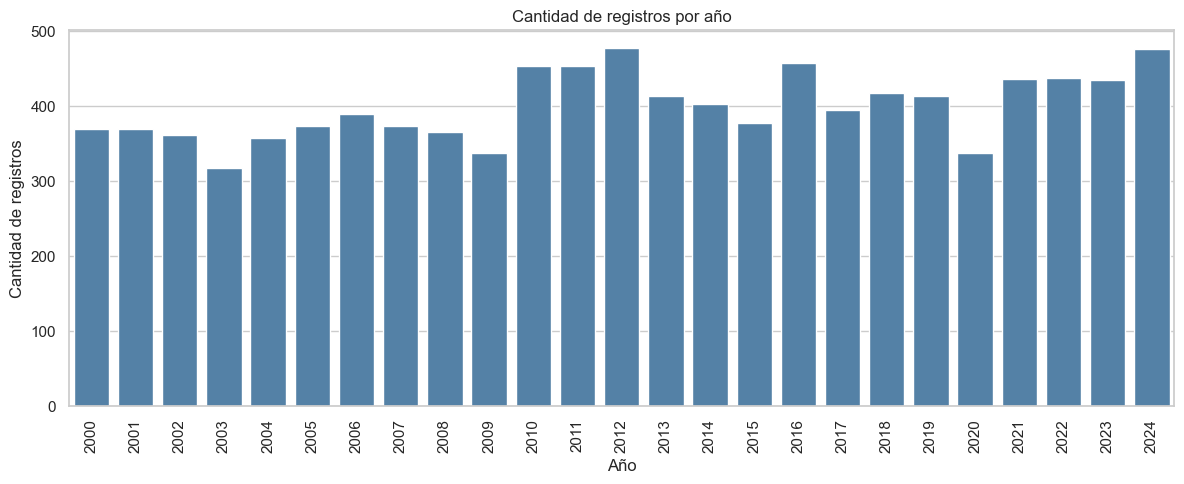

In [13]:
# ============================================================
# 9.1) ANÁLISIS GENERAL DE LA BASE
# ============================================================

print("=" * 80)
print("9.1) ANÁLISIS GENERAL DE LA BASE")
print("=" * 80)

resumen_general = {
    "observaciones": base_eda.shape[0],
    "variables": base_eda.shape[1],
    "anio_minimo": base_eda["year"].min() if "year" in base_eda.columns else np.nan,
    "anio_maximo": base_eda["year"].max() if "year" in base_eda.columns else np.nan,
    "carreras_unicas": base_eda["raceId"].nunique() if "raceId" in base_eda.columns else np.nan,
    "pilotos_unicos": base_eda["driverId"].nunique() if "driverId" in base_eda.columns else np.nan,
    "constructores_unicos": base_eda["constructorId"].nunique() if "constructorId" in base_eda.columns else np.nan,
    "circuitos_unicos": base_eda["circuitId"].nunique() if "circuitId" in base_eda.columns else np.nan
}

resumen_general = pd.DataFrame.from_dict(
    resumen_general,
    orient="index",
    columns=["valor"]
)

display(resumen_general)

resumen_general.to_csv(DATA_PROCESSED / "formula1_resumen_general_eda.csv")

print("\nTipos de datos:")
tipos_datos = (
    base_eda.dtypes
    .reset_index()
    .rename(columns={"index": "variable", 0: "tipo"})
)
display(tipos_datos)

# Registros por año
if "year" in base_eda.columns:
    plt.figure(figsize=(12, 5))
    conteos_anio = base_eda["year"].value_counts().sort_index()
    sns.barplot(
        x=conteos_anio.index.astype(str),
        y=conteos_anio.values,
        color="steelblue"
    )
    plt.title("Cantidad de registros por año")
    plt.xlabel("Año")
    plt.ylabel("Cantidad de registros")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "eda_registros_por_anio.png", dpi=300, bbox_inches="tight")
    plt.show()


## 9.2 Selección de variables para el EDA

Para evitar errores de interpretación, no se tratan todas las columnas numéricas de la misma forma.

Los identificadores (`raceId`, `driverId`, etc.) son números, pero no representan magnitudes deportivas. Por eso se excluyen de las correlaciones principales. En cambio, se conservan variables como posición de largada, posición final, puntos, vueltas, edad del piloto, posición en campeonato y características del circuito.


In [14]:
# ============================================================
# 9.2) SELECCIÓN DE VARIABLES
# ============================================================

# Identificadores técnicos: son numéricos, pero no tienen sentido analítico directo.
columnas_id = [
    "resultId",
    "raceId",
    "driverId",
    "constructorId",
    "statusId",
    "circuitId"
]

# Cambiar a True solo si se quiere forzar la inclusión de IDs en el heatmap/pairplot.
INCLUIR_IDS_EN_CORRELACION = False

variables_numericas_detectadas = (
    base_eda
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

if INCLUIR_IDS_EN_CORRELACION:
    variables_numericas_eda = variables_numericas_detectadas
else:
    variables_numericas_eda = [
        col for col in variables_numericas_detectadas
        if col not in columnas_id
    ]

# Eliminar columnas constantes, porque no aportan correlación.
variables_numericas_eda = [
    col for col in variables_numericas_eda
    if base_eda[col].nunique(dropna=True) > 1
]

# Variables candidatas para PCA.
# Esta lista es más estricta que la del EDA: evita IDs y evita variables binarias
# muy derivadas de la posición final, como podio/top10/victoria.
# Variables candidatas para PCA: alineadas con las que usa efectivamente el notebook de PCA.
# - Se usa laps_pct en lugar de laps (proporción de carrera completada; comparable entre carreras).
# - Se excluyen race_points y driver_championship_points: el sistema de puntuación cambió a lo largo del tiempo.
# - Se excluye circuit_alt: genera un eje asociado a altitud del circuito, no a rendimiento deportivo.
variables_pca_candidatas = [
    "grid",
    "positionOrder",
    "laps_pct",
    "driver_age",
    "driver_championship_position",
    "driver_championship_wins"
]

variables_pca_candidatas = [
    col for col in variables_pca_candidatas
    if col in base_eda.columns
]

variables_categoricas_eda = [
    "decada",
    "resultado_grupo",
    "largada_grupo",
    "status_grupo",
    "circuit_country",
    "driver_nationality",
    "constructor_nationality",
    "constructor_name"
]

variables_categoricas_eda = [
    col for col in variables_categoricas_eda
    if col in base_eda.columns
]

print("Variables numéricas detectadas originalmente:")
print(variables_numericas_detectadas)

print("\nVariables numéricas usadas en el EDA:")
print(variables_numericas_eda)

print("\nVariables candidatas para PCA:")
print(variables_pca_candidatas)

print("\nVariables categóricas usadas en el EDA:")
print(variables_categoricas_eda)


Variables numéricas detectadas originalmente:
['year', 'round', 'driver_age', 'grid', 'positionOrder', 'race_points', 'laps', 'driver_championship_points', 'driver_championship_position', 'driver_championship_wins', 'resultId', 'raceId', 'driverId', 'constructorId', 'statusId', 'circuitId', 'circuit_lat', 'circuit_lng', 'circuit_alt', 'podio', 'top10', 'victoria', 'laps_max_race', 'laps_pct', 'vueltas_perdidas']

Variables numéricas usadas en el EDA:
['year', 'round', 'driver_age', 'grid', 'positionOrder', 'race_points', 'laps', 'driver_championship_points', 'driver_championship_position', 'driver_championship_wins', 'circuit_lat', 'circuit_lng', 'circuit_alt', 'podio', 'top10', 'victoria', 'laps_max_race', 'laps_pct', 'vueltas_perdidas']

Variables candidatas para PCA:
['grid', 'positionOrder', 'laps_pct', 'driver_age', 'driver_championship_position', 'driver_championship_wins']

Variables categóricas usadas en el EDA:
['decada', 'resultado_grupo', 'largada_grupo', 'status_grupo', 'ci

## 9.3 Análisis univariado de variables numéricas

Se analizan medidas descriptivas, distribuciones e identificación visual de posibles valores extremos. Esta parte ayuda a entender rangos, asimetrías y variables que podrían necesitar estandarización antes del PCA.


In [15]:
# ============================================================
# 9.3) ANÁLISIS UNIVARIADO DE VARIABLES NUMÉRICAS
# ============================================================

print("=" * 80)
print("9.3) ANÁLISIS UNIVARIADO DE VARIABLES NUMÉRICAS")
print("=" * 80)

df_num_eda = base_eda[variables_numericas_eda].copy()

for col in df_num_eda.columns:
    df_num_eda[col] = pd.to_numeric(df_num_eda[col], errors="coerce")

descripcion_numerica = df_num_eda.describe().T
descripcion_numerica["n_faltantes"] = df_num_eda.isna().sum()
descripcion_numerica["porcentaje_faltante"] = df_num_eda.isna().mean() * 100

display(descripcion_numerica.round(3))

descripcion_numerica.to_csv(DATA_PROCESSED / "formula1_descripcion_numerica_eda.csv")


9.3) ANÁLISIS UNIVARIADO DE VARIABLES NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max,n_faltantes,porcentaje_faltante
year,10000.0,2012.457,7.165,2000.000,2006.000,2012.500,2019.000,2024.000,0,0.00
round,10000.0,10.163,5.696,1.000,5.000,10.000,15.000,24.000,0,0.00
driver_age,10000.0,28.267,5.012,17.454,24.372,27.504,31.563,43.893,0,0.00
grid,10000.0,10.890,6.189,0.000,6.000,11.000,16.000,24.000,0,0.00
positionOrder,10000.0,11.069,6.162,1.000,6.000,11.000,16.000,24.000,0,0.00
race_points,10000.0,3.688,6.151,0.000,0.000,0.000,6.000,50.000,0,0.00
laps,10000.0,52.110,19.233,0.000,50.000,56.000,66.000,87.000,0,0.00
driver_championship_points,9847.0,39.414,64.655,0.000,1.000,12.000,46.000,575.000,153,1.53
driver_championship_position,9847.0,11.164,6.368,1.000,6.000,11.000,16.000,27.000,153,1.53
driver_championship_wins,9847.0,0.492,1.516,0.000,0.000,0.000,0.000,19.000,153,1.53


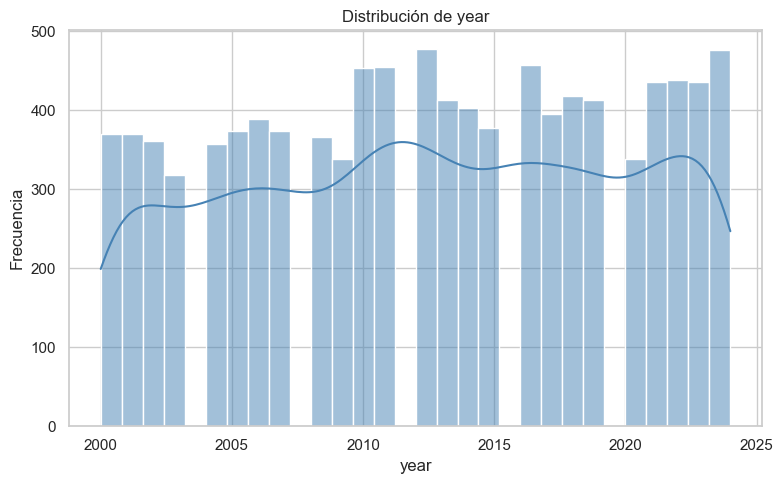

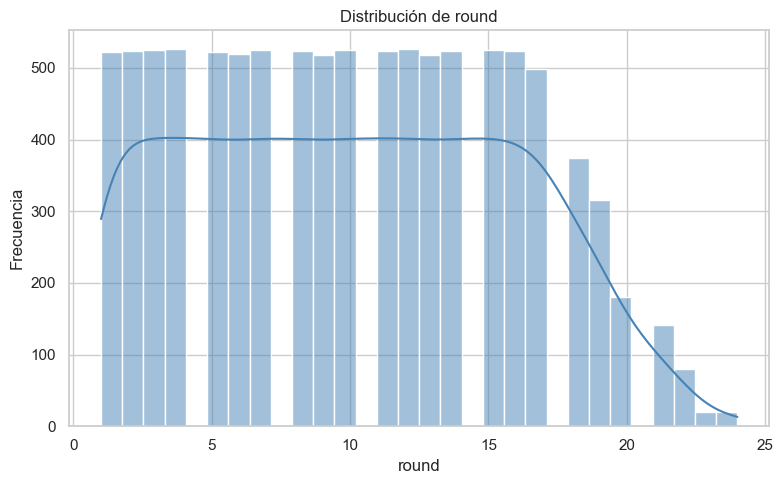

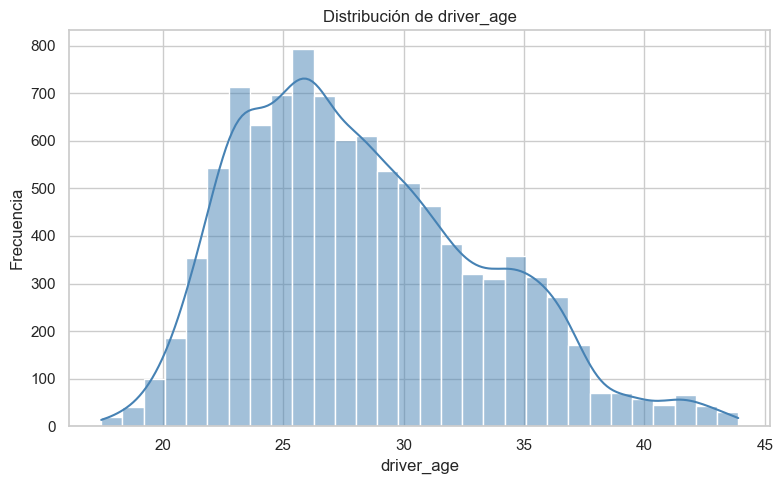

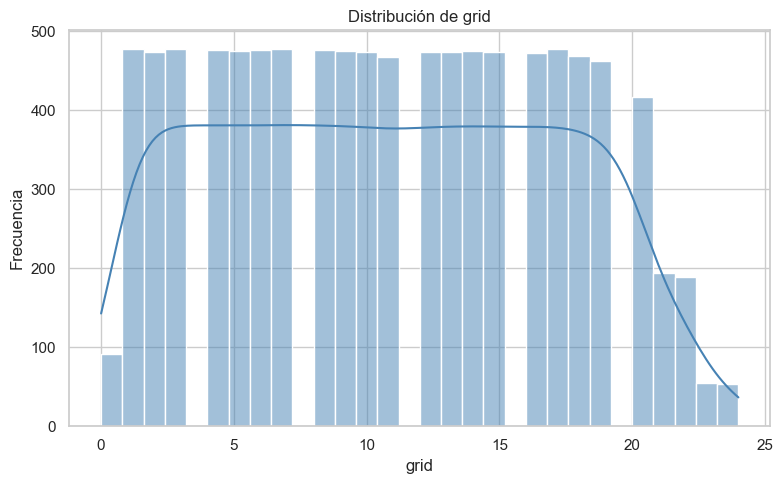

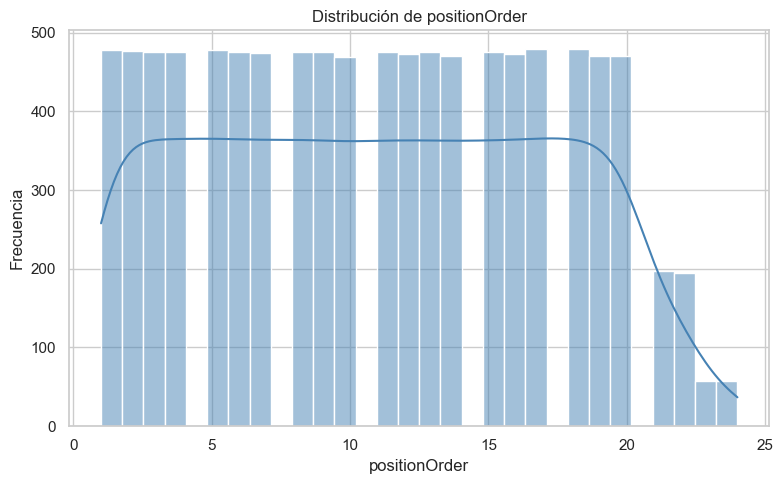

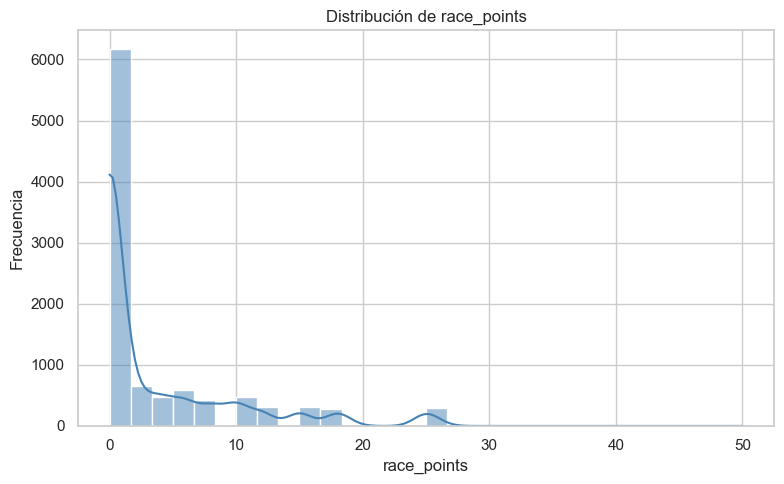

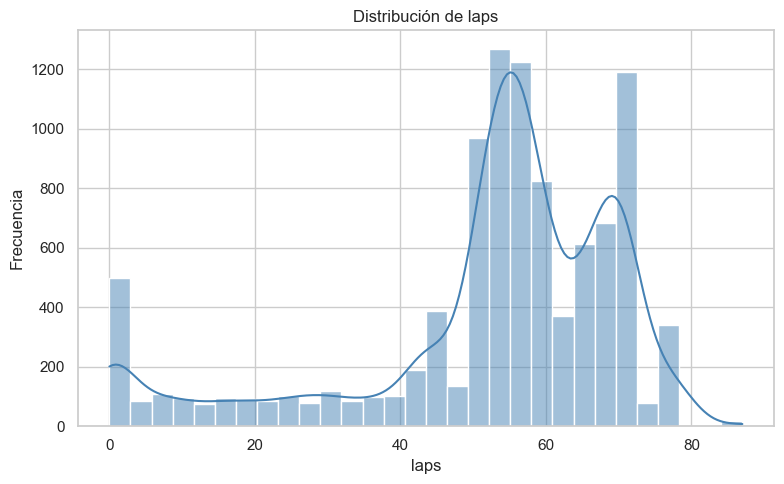

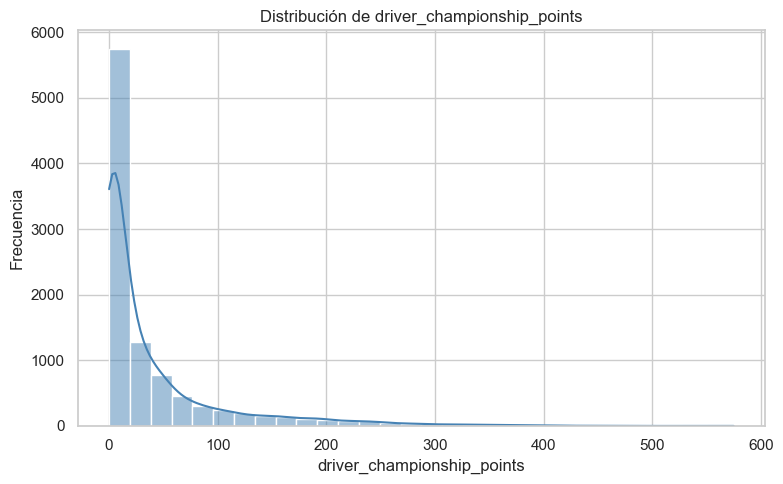

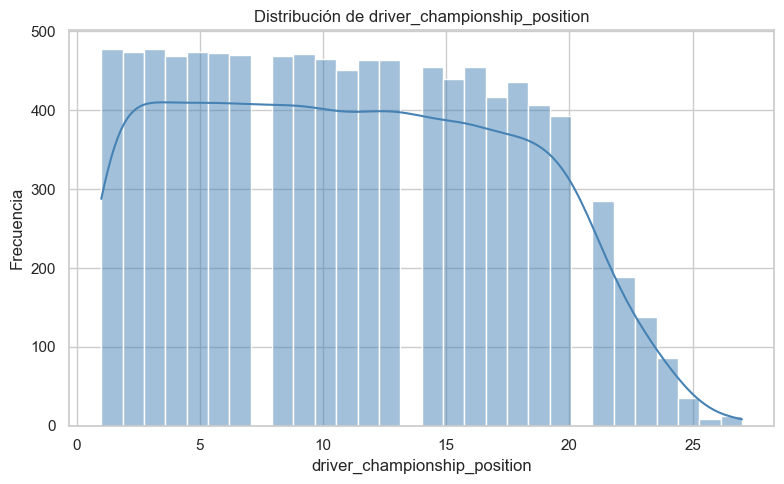

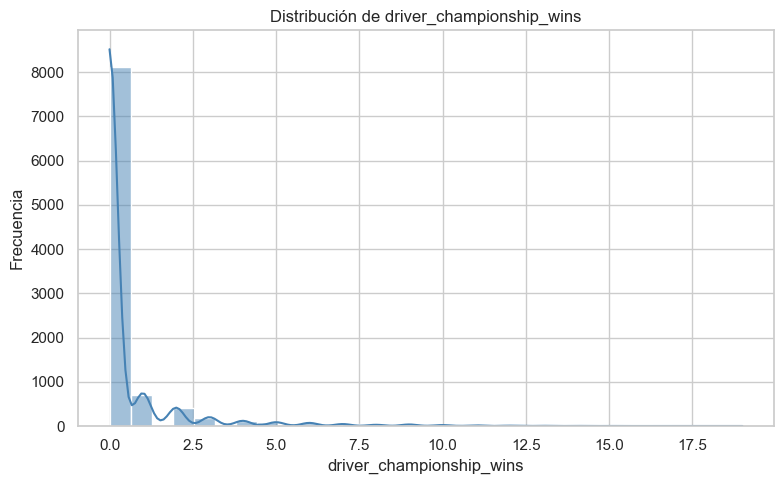

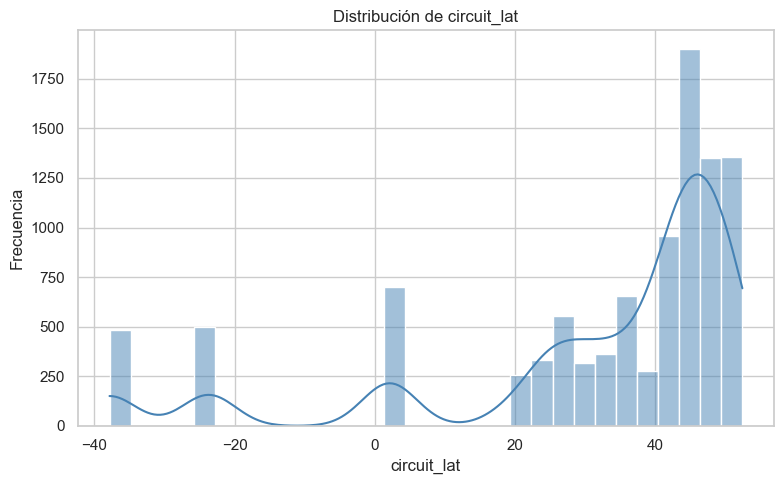

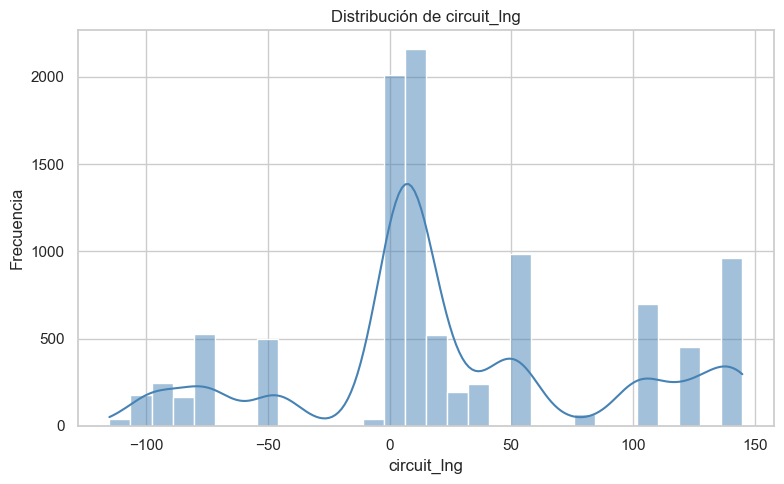

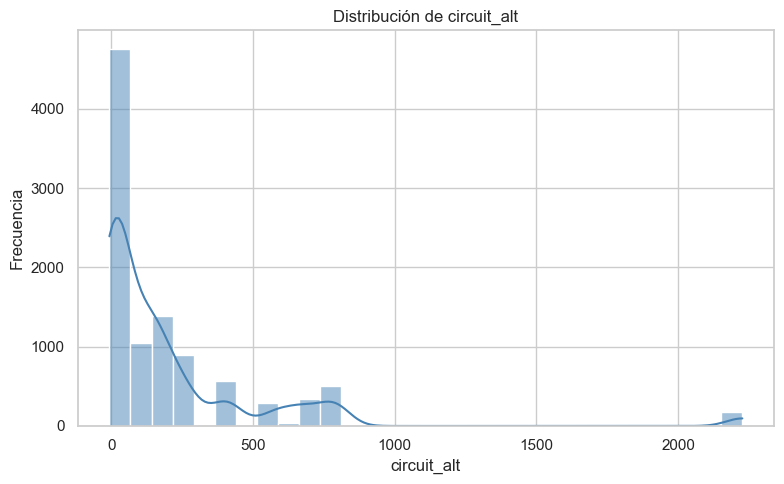

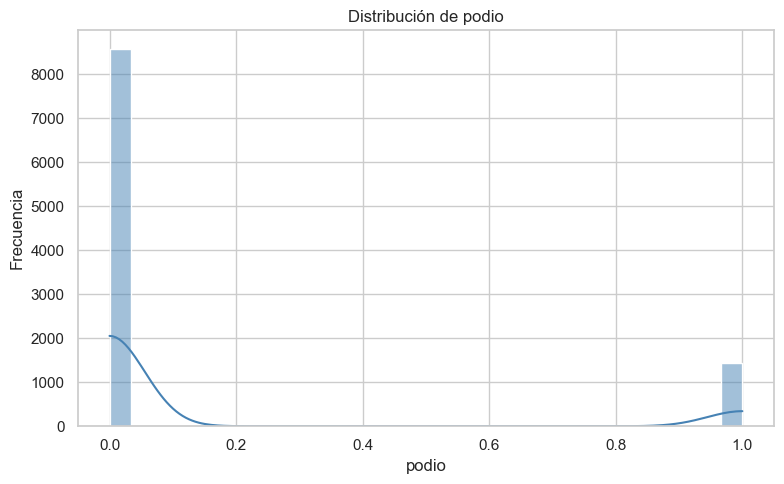

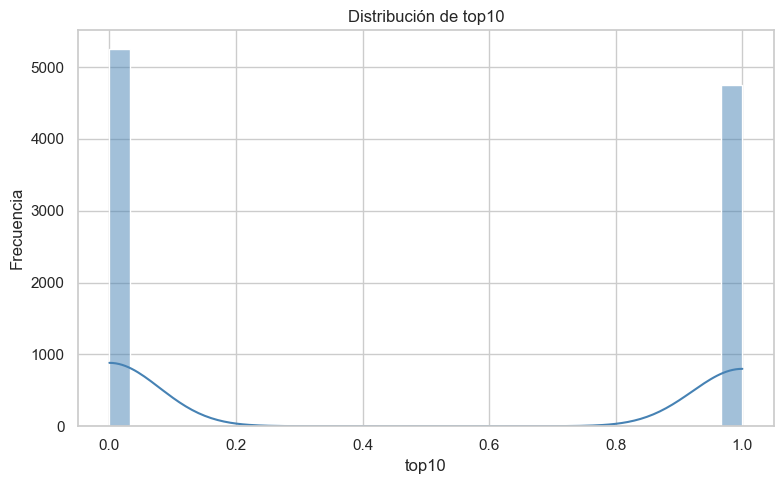

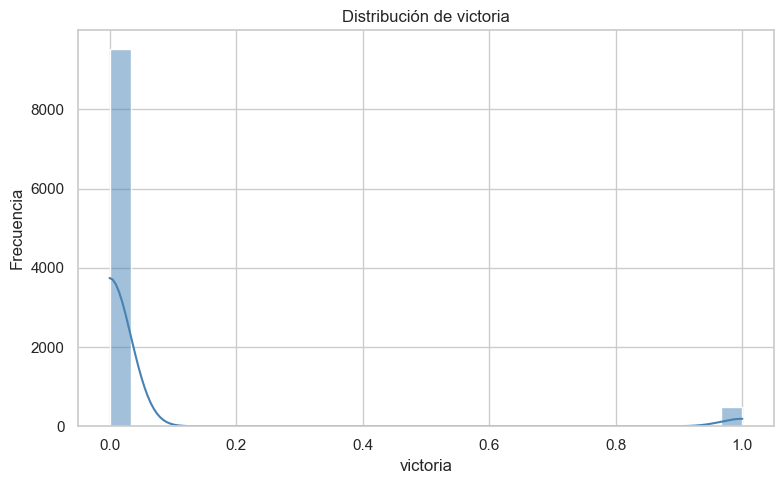

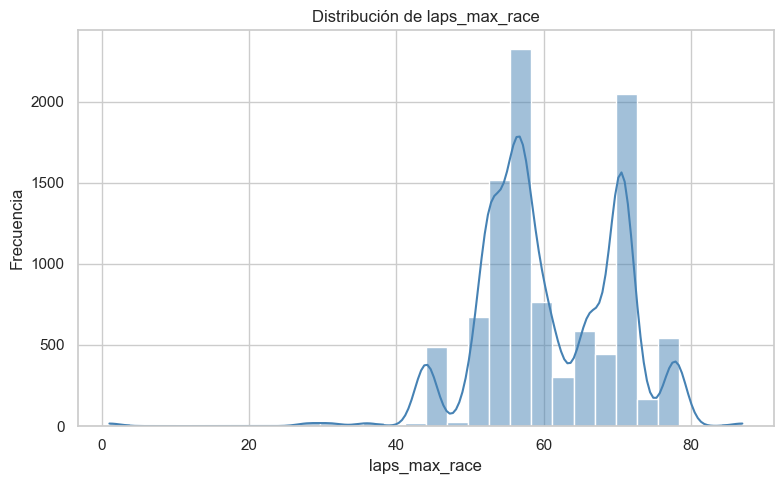

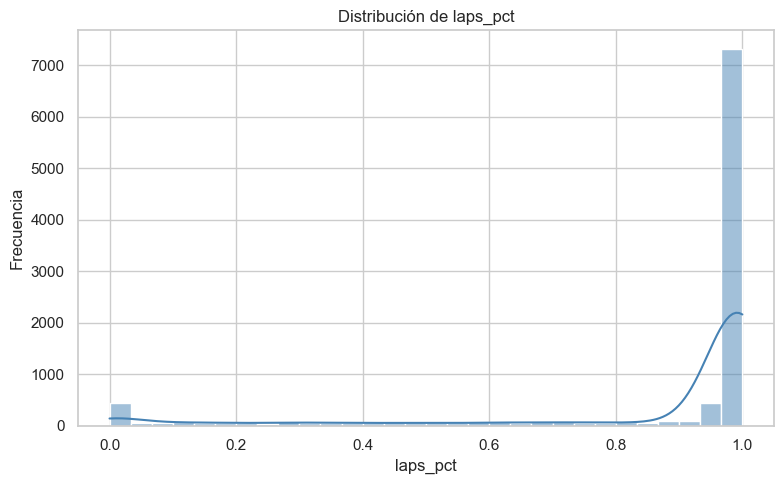

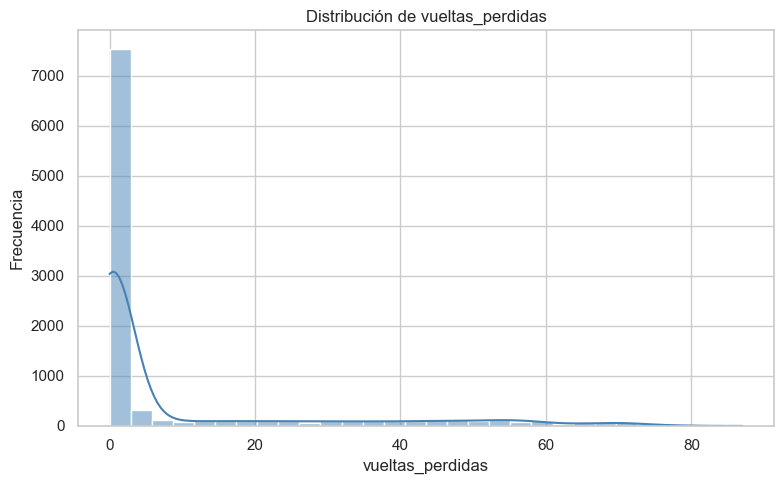

In [16]:
# Histogramas de variables numéricas

for col in variables_numericas_eda:
    serie = pd.to_numeric(base_eda[col], errors="coerce").dropna()

    if serie.empty:
        continue

    plt.figure(figsize=(8, 5))
    sns.histplot(serie, bins=30, kde=True, color="steelblue")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"eda_histograma_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()


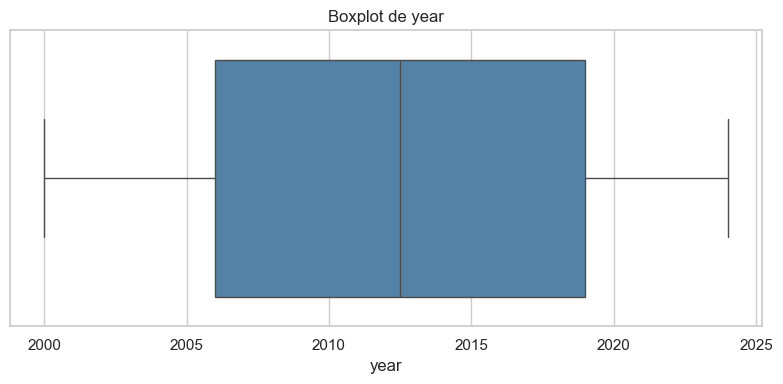

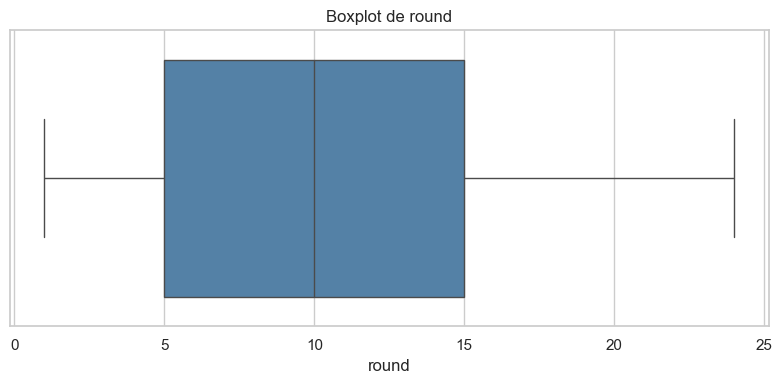

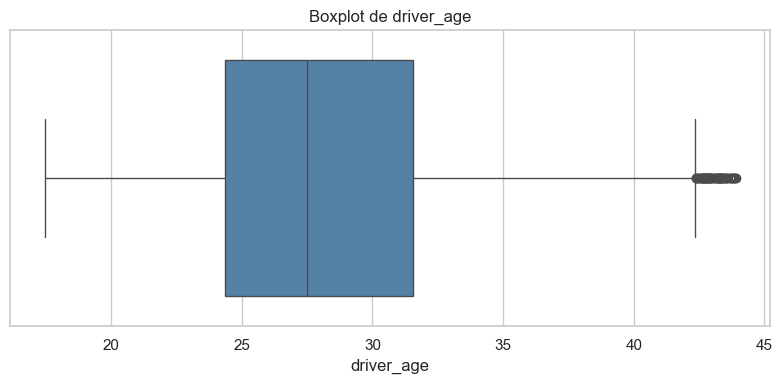

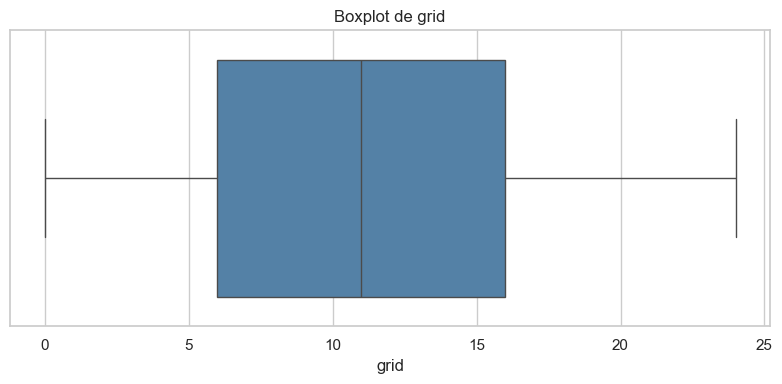

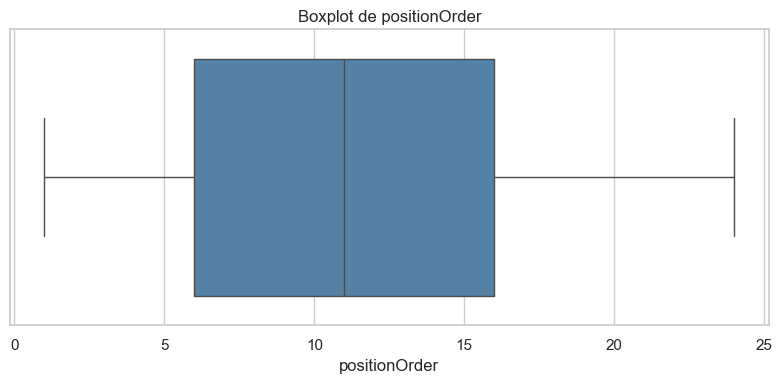

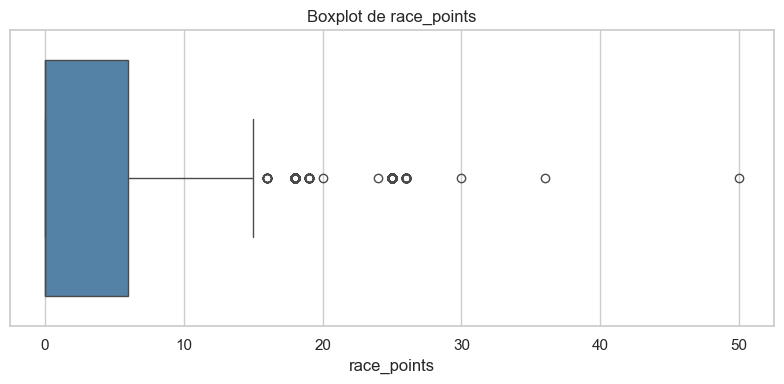

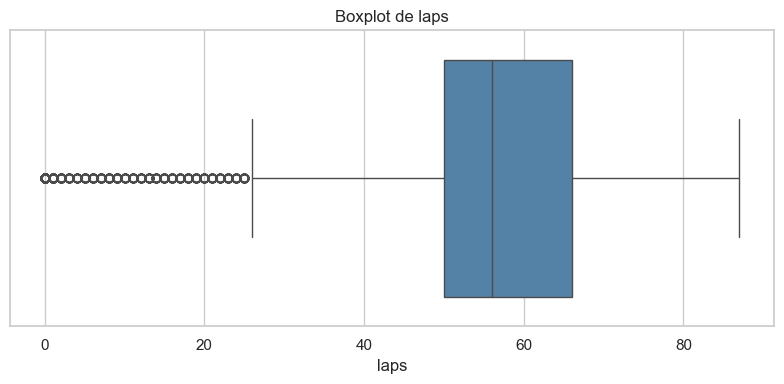

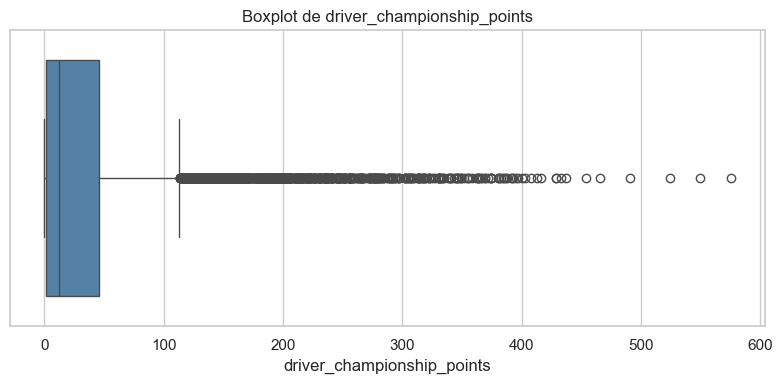

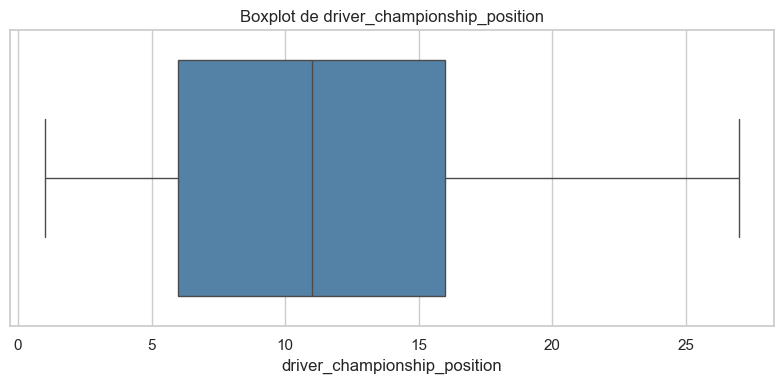

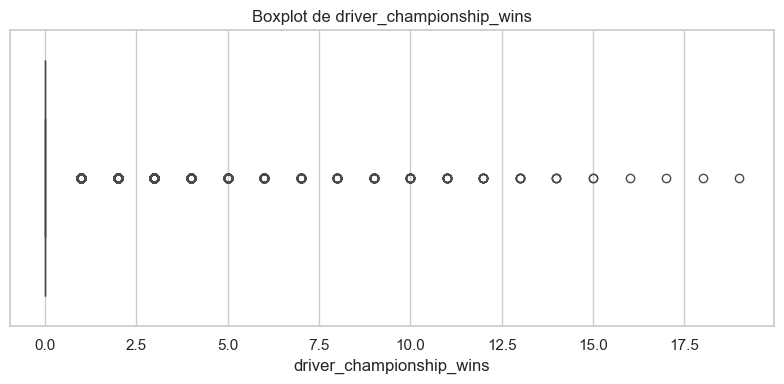

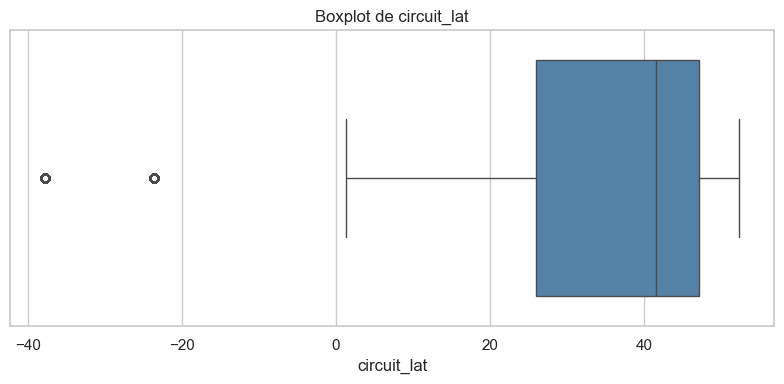

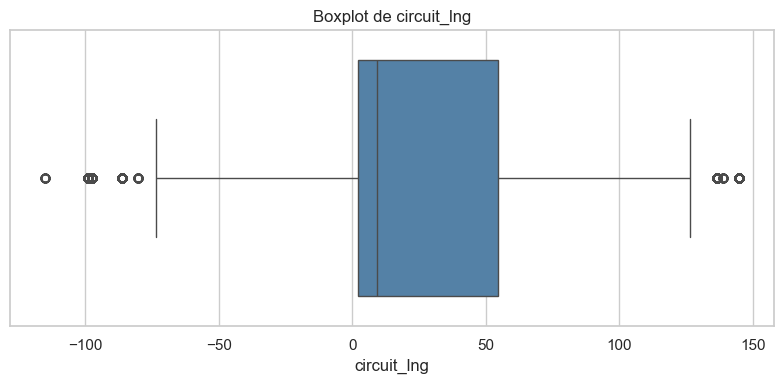

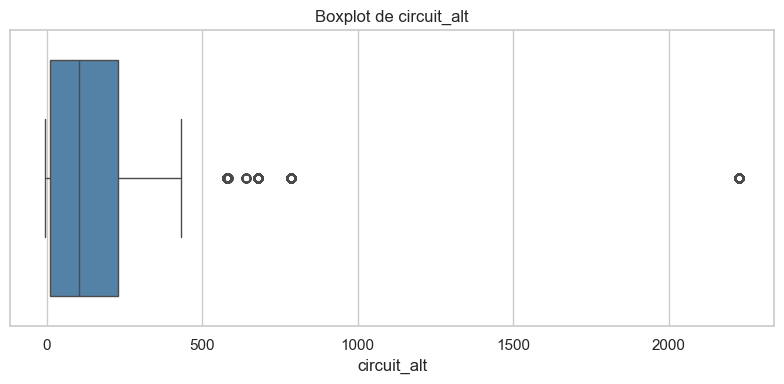

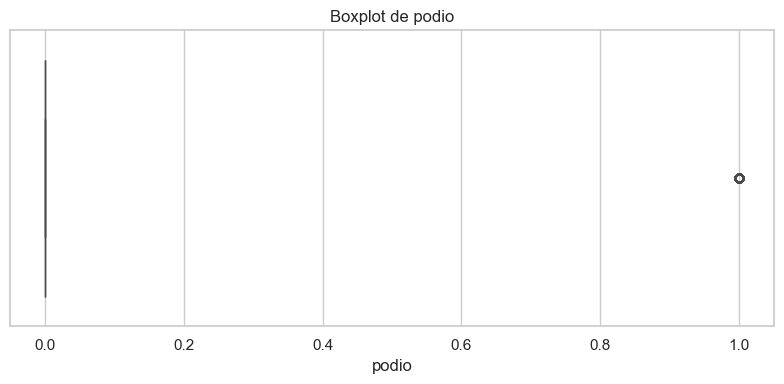

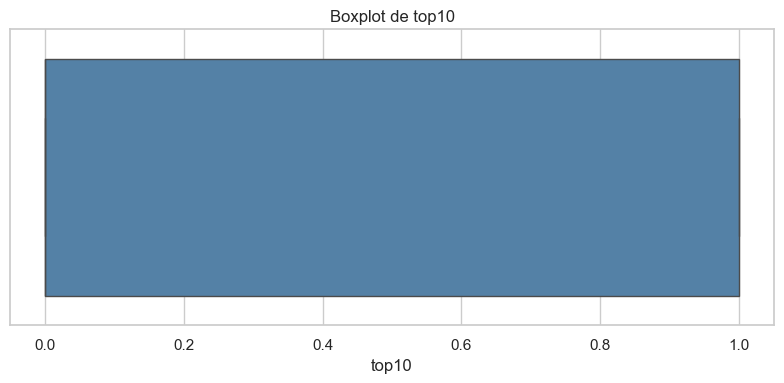

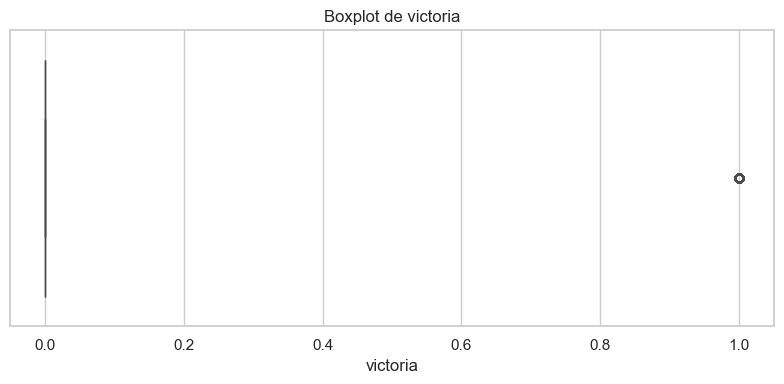

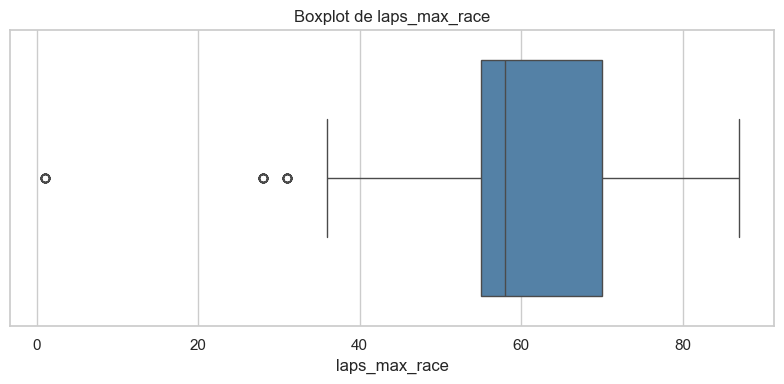

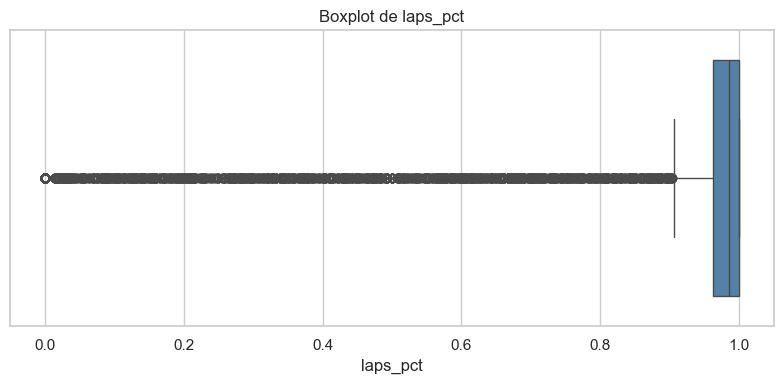

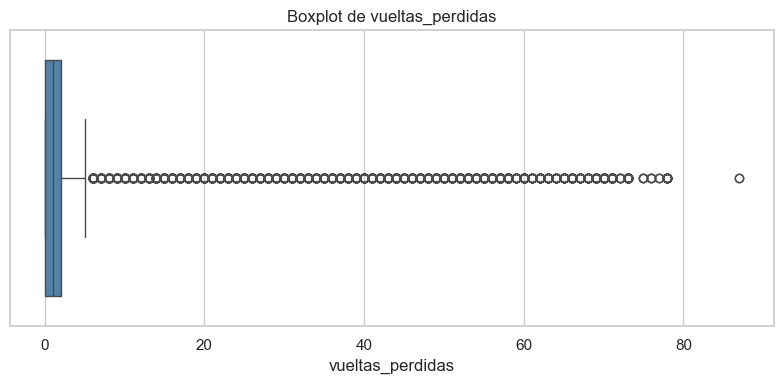

In [17]:
# Boxplots de variables numéricas

for col in variables_numericas_eda:
    serie = pd.to_numeric(base_eda[col], errors="coerce").dropna()

    if serie.empty:
        continue

    plt.figure(figsize=(8, 4))
    sns.boxplot(x=serie, color="steelblue")
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"eda_boxplot_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()


## 9.4 Análisis de variables categóricas

Se revisan las principales categorías de la base: décadas, grupos de resultado, grupos de largada, estado final de carrera, países de circuitos, nacionalidades de pilotos y constructores.


In [18]:
# ============================================================
# 9.4) ANÁLISIS DE VARIABLES CATEGÓRICAS
# ============================================================

print("=" * 80)
print("9.4) ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("=" * 80)

for col in variables_categoricas_eda:
    print("\n" + "-" * 80)
    print(col)
    print("-" * 80)

    tabla_frecuencias = (
        base_eda[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="frecuencia")
    )

    tabla_frecuencias["porcentaje"] = (
        tabla_frecuencias["frecuencia"] / len(base_eda) * 100
    )

    display(tabla_frecuencias.head(15))

    tabla_frecuencias.to_csv(
        DATA_PROCESSED / f"formula1_frecuencias_{col}.csv",
        index=False
    )


9.4) ANÁLISIS DE VARIABLES CATEGÓRICAS

--------------------------------------------------------------------------------
decada
--------------------------------------------------------------------------------


,decada,frecuencia,porcentaje
0,2010s,4261,42.61
1,2000s,3616,36.16
2,2020s,2123,21.23



--------------------------------------------------------------------------------
resultado_grupo
--------------------------------------------------------------------------------


,resultado_grupo,frecuencia,porcentaje
0,Fuera del top 10,5248,52.48
1,Top 10,3322,33.22
2,Podio,952,9.52
3,Ganador,478,4.78



--------------------------------------------------------------------------------
largada_grupo
--------------------------------------------------------------------------------


...

,driver_nationality,frecuencia,porcentaje
0,German,1587,15.87
1,British,1345,13.45
2,Spanish,777,7.77
3,Finnish,772,7.72
4,Brazilian,757,7.57
5,French,753,7.53
6,Italian,559,5.59
7,Australian,514,5.14
8,Mexican,342,3.42
9,Dutch,340,3.40



--------------------------------------------------------------------------------
constructor_nationality
--------------------------------------------------------------------------------


,constructor_nationality,frecuencia,porcentaje
0,British,2961,29.61
1,Italian,1961,19.61
2,Swiss,810,8.10
3,French,798,7.98
4,Austrian,782,7.82
5,German,741,7.41
6,Japanese,461,4.61
7,Indian,422,4.22
8,American,378,3.78
9,Irish,207,2.07



--------------------------------------------------------------------------------
constructor_name
--------------------------------------------------------------------------------


,constructor_name,frecuencia,porcentaje
0,McLaren,952,9.52
1,Williams,951,9.51
2,Ferrari,950,9.50
3,Red Bull,782,7.82
4,Sauber,605,6.05
5,Mercedes,601,6.01
6,Renault,553,5.53
7,Toro Rosso,526,5.26
8,Force India,422,4.22
9,Haas F1 Team,378,3.78


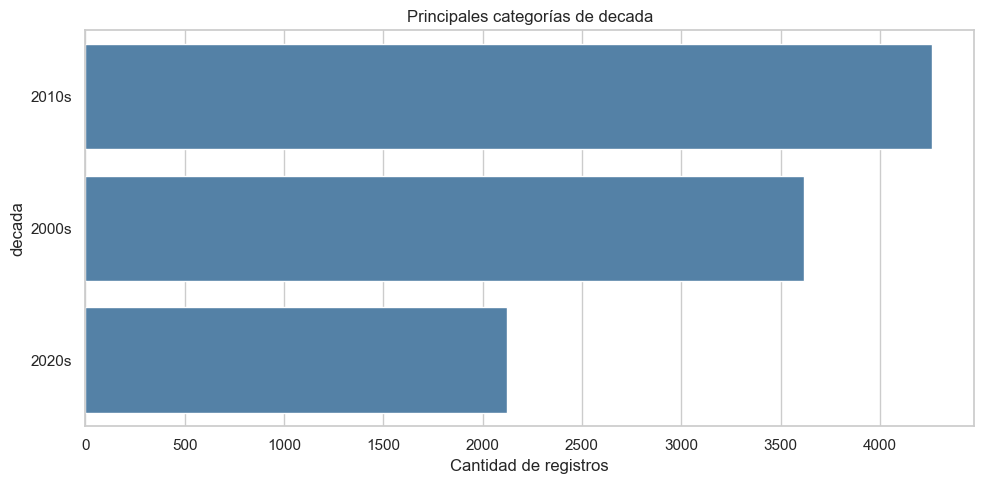

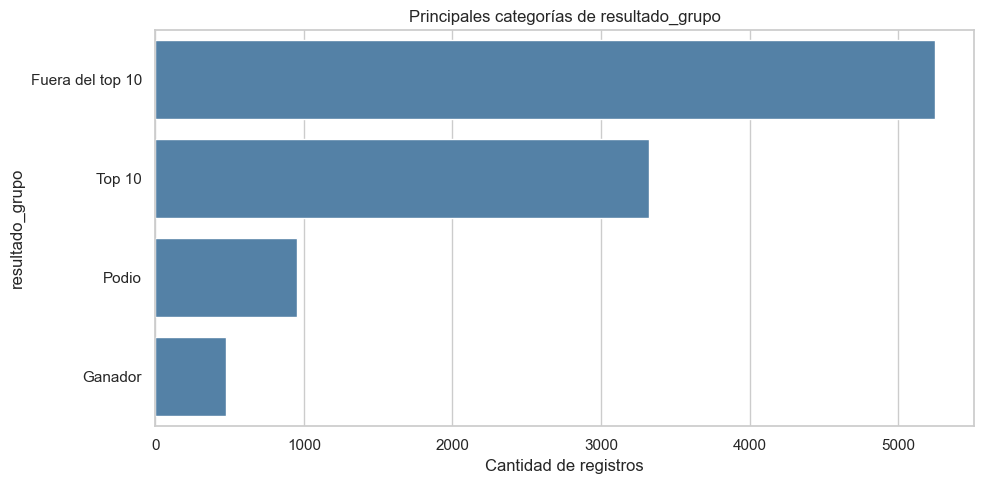

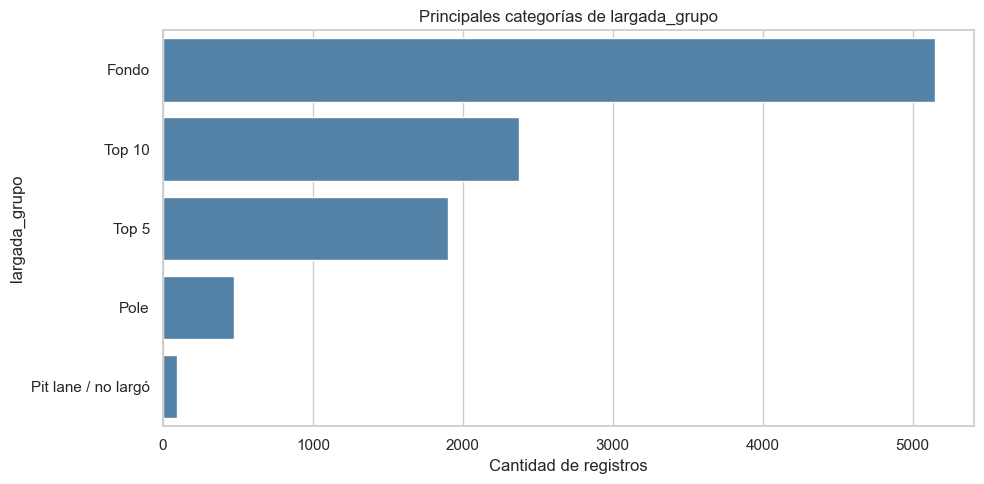

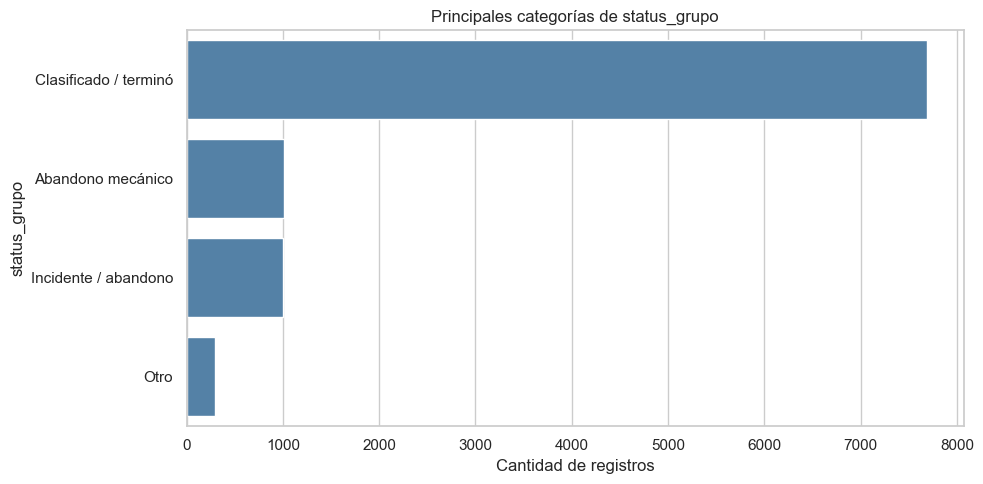

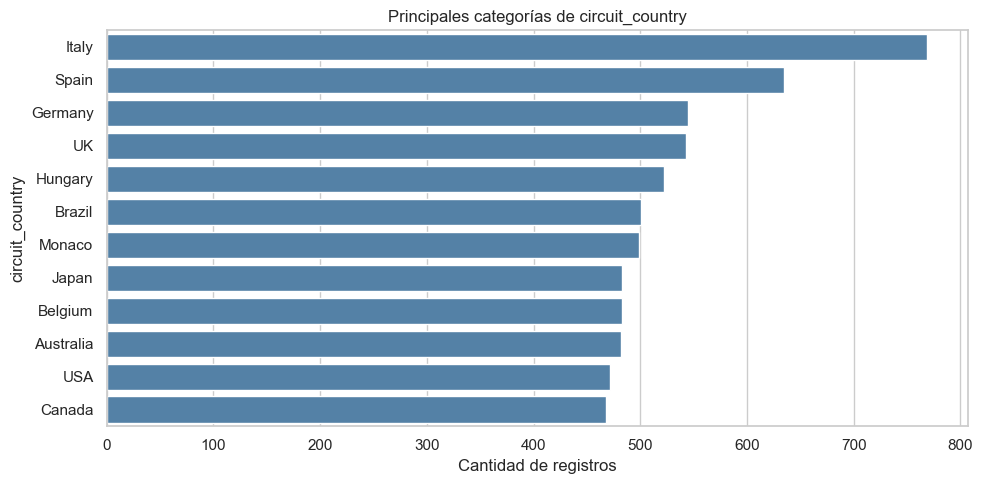

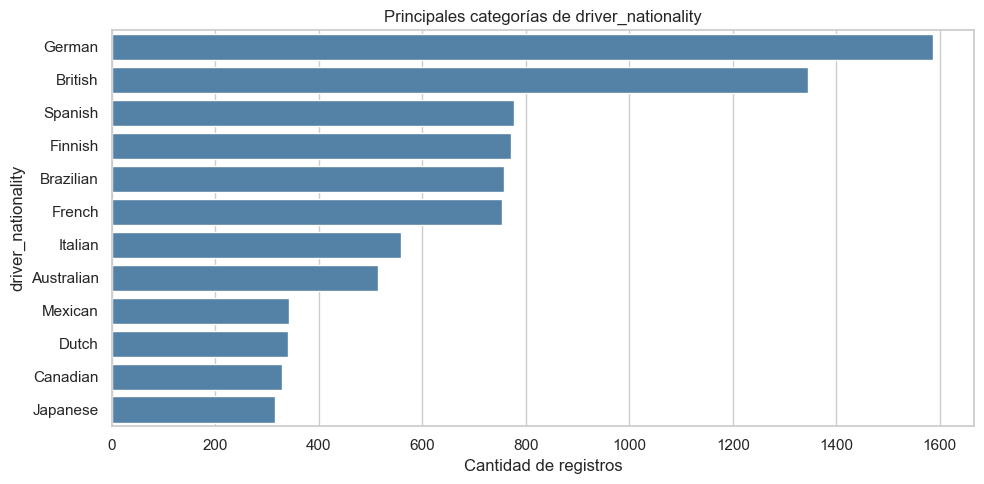

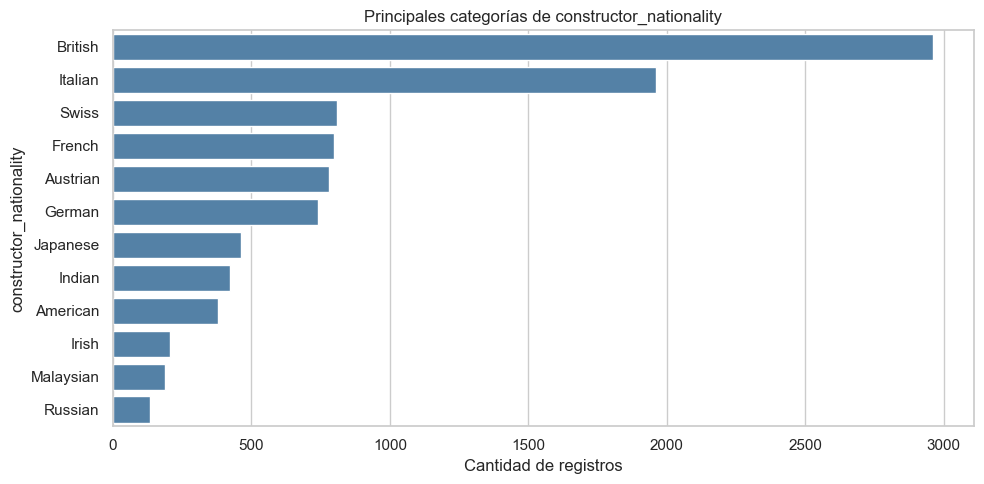

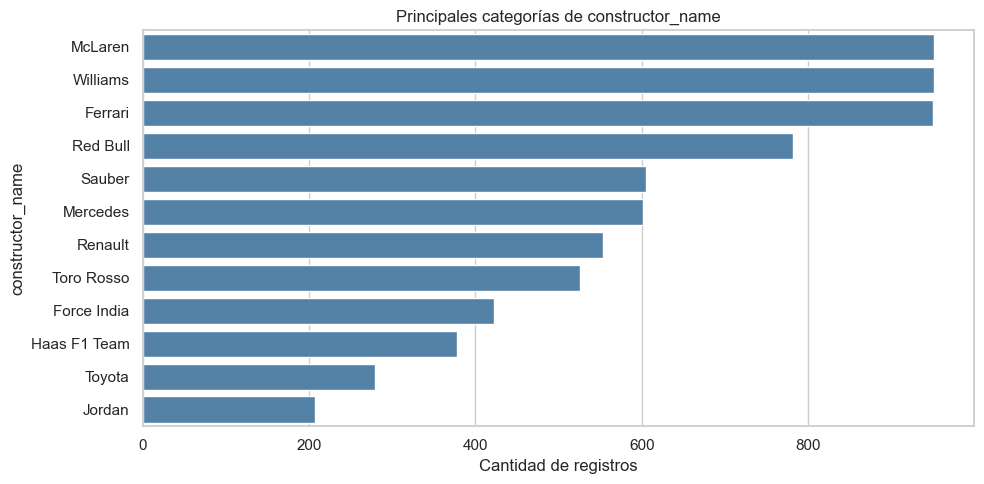

In [19]:
# Gráficos de top categorías

def graficar_top_categorias(df, columna, top_n=12):
    conteos = df[columna].value_counts(dropna=False).head(top_n)

    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=conteos.values,
        y=conteos.index.astype(str),
        color="steelblue"
    )
    plt.title(f"Principales categorías de {columna}")
    plt.xlabel("Cantidad de registros")
    plt.ylabel(columna)
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"eda_top_categorias_{columna}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

for col in variables_categoricas_eda:
    graficar_top_categorias(base_eda, col, top_n=12)


## 9.5 Relaciones bivariadas principales

Antes de avanzar con PCA y clustering, se observan algunas relaciones deportivas centrales:

- posición de largada vs. posición final;
- posición final vs. puntos obtenidos;
- posición en campeonato vs. puntos acumulados.

Estos gráficos ayudan a evaluar si existen asociaciones lineales o tendencias claras entre variables.


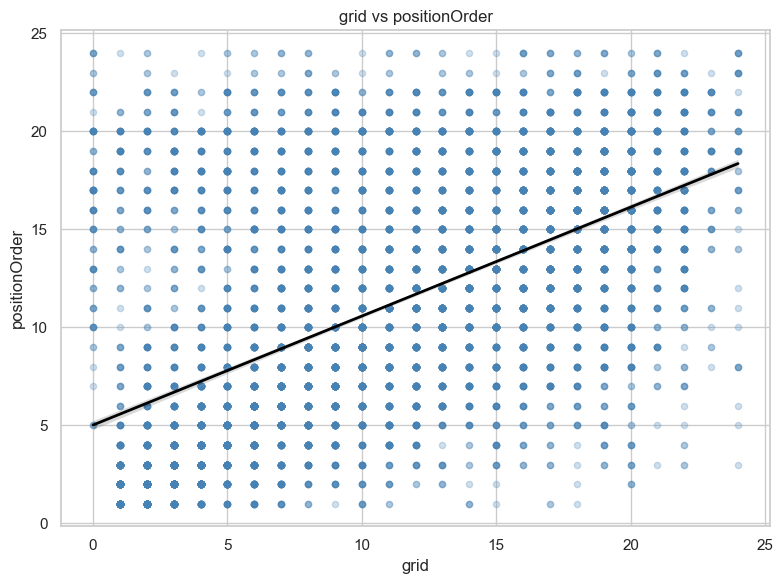

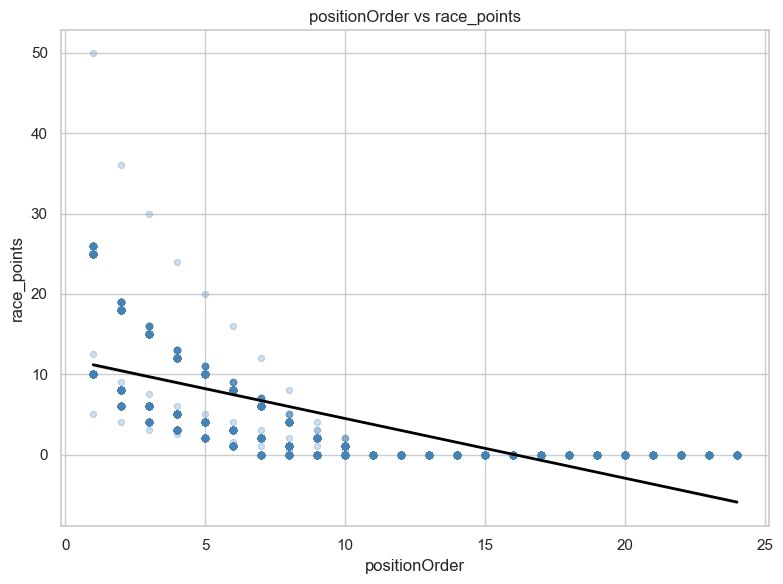

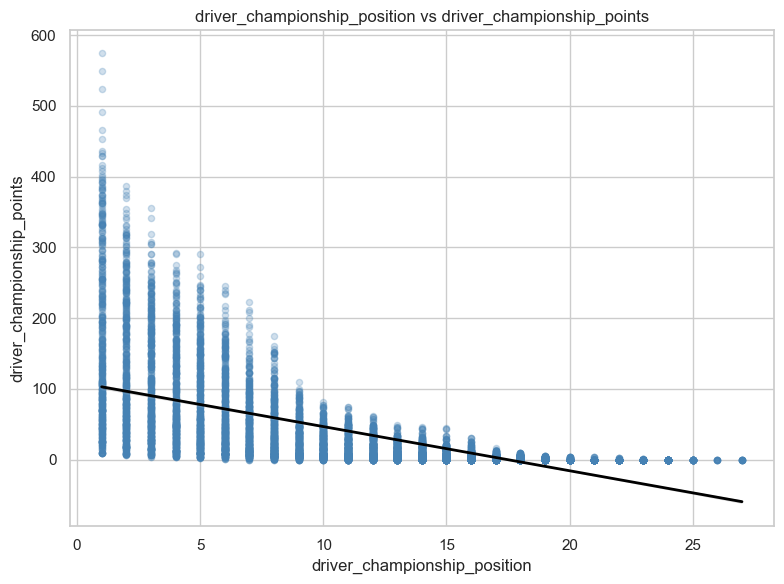

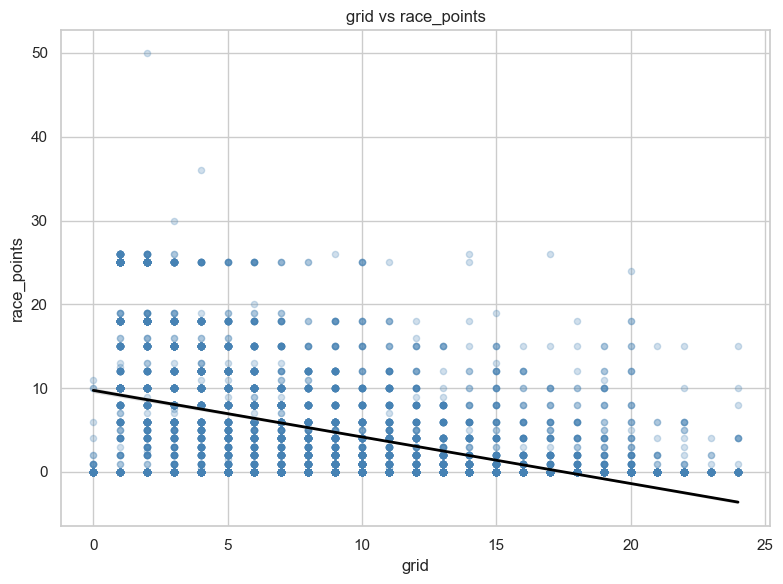

In [20]:
# ============================================================
# 9.5) RELACIONES BIVARIADAS PRINCIPALES
# ============================================================

def scatter_con_regresion(df, x, y, nombre_archivo):
    datos = df[[x, y]].copy()
    datos[x] = pd.to_numeric(datos[x], errors="coerce")
    datos[y] = pd.to_numeric(datos[y], errors="coerce")
    datos = datos.dropna()

    if datos.empty:
        print(f"No hay datos suficientes para graficar {x} vs {y}.")
        return

    plt.figure(figsize=(8, 6))
    sns.regplot(
        data=datos,
        x=x,
        y=y,
        color="steelblue",
        scatter_kws={"alpha": 0.25, "s": 20},
        line_kws={"linewidth": 2, "color": "black"}
    )
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / nombre_archivo, dpi=300, bbox_inches="tight")
    plt.show()

pares_bivariados = [
    ("grid", "positionOrder", "eda_largada_vs_posicion_final.png"),
    ("positionOrder", "race_points", "eda_posicion_final_vs_puntos.png"),
    ("driver_championship_position", "driver_championship_points", "eda_posicion_campeonato_vs_puntos_campeonato.png"),
    ("grid", "race_points", "eda_largada_vs_puntos.png")
]

for x, y, archivo in pares_bivariados:
    if x in base_eda.columns and y in base_eda.columns:
        scatter_con_regresion(base_eda, x, y, archivo)


## 9.6 Matriz de correlación con variables numéricas

Esta matriz resume la asociación lineal entre las variables numéricas interpretables. Sirve como diagnóstico previo al PCA: si hay grupos de variables correlacionadas, el PCA puede resumir parte de esa información en componentes principales.


9.6) HEATMAP DE CORRELACIÓN


,year,round,driver_age,grid,positionOrder,race_points,laps,driver_championship_points,driver_championship_position,driver_championship_wins,circuit_lat,circuit_lng,circuit_alt,podio,top10,victoria,laps_max_race,laps_pct,vueltas_perdidas
year,1.000,0.151,-0.033,-0.064,-0.041,0.231,0.101,0.275,-0.027,0.029,-0.013,-0.045,0.068,0.010,0.022,0.005,-0.123,0.163,-0.174
round,0.151,1.000,0.027,-0.010,-0.011,0.039,0.028,0.381,0.031,0.179,0.064,-0.212,0.313,0.003,0.006,0.002,-0.075,0.064,-0.070
driver_age,-0.033,0.027,1.000,-0.113,-0.079,0.081,0.020,0.107,-0.140,0.065,0.009,-0.013,0.004,0.066,0.083,0.038,0.006,0.021,-0.018
grid,-0.064,-0.010,-0.113,1.000,0.558,-0.559,-0.114,-0.483,0.726,-0.369,-0.003,0.018,-0.015,-0.480,-0.516,-0.311,-0.002,-0.124,0.122
positionOrder,-0.041,-0.011,-0.079,0.558,1.000,-0.745,-0.569,-0.441,0.655,-0.354,-0.004,0.014,-0.012,-0.601,-0.862,-0.366,-0.002,-0.623,0.613
race_points,0.231,0.039,0.081,-0.559,-0.745,1.000,0.255,0.656,-0.620,0.508,-0.007,-0.002,0.010,0.762,0.630,0.581,-0.027,0.292,-0.289
laps,0.101,0.028,0.020,-0.114,-0.569,0.255,1.000,0.097,-0.164,0.079,0.030,-0.148,0.101,0.184,0.414,0.101,0.388,0.896,-0.875
driver_championship_points,0.275,0.381,0.107,-0.483,-0.441,0.656,0.097,1.000,-0.615,0.717,-0.028,-0.083,0.137,0.463,0.385,0.340,-0.053,0.130,-0.133
driver_championship_position,-0.027,0.031,-0.140,0.726,0.655,-0.620,-0.164,-0.615,1.000,-0.461,0.024,-0.002,-0.007,-0.517,-0.606,-0.323,-0.003,-0.179,0.176
driver_championship_wins,0.029,0.179,0.065,-0.369,-0.354,0.508,0.079,0.717,-0.461,1.000,0.003,-0.038,0.059,0.482,0.262,0.531,-0.015,0.092,-0.094


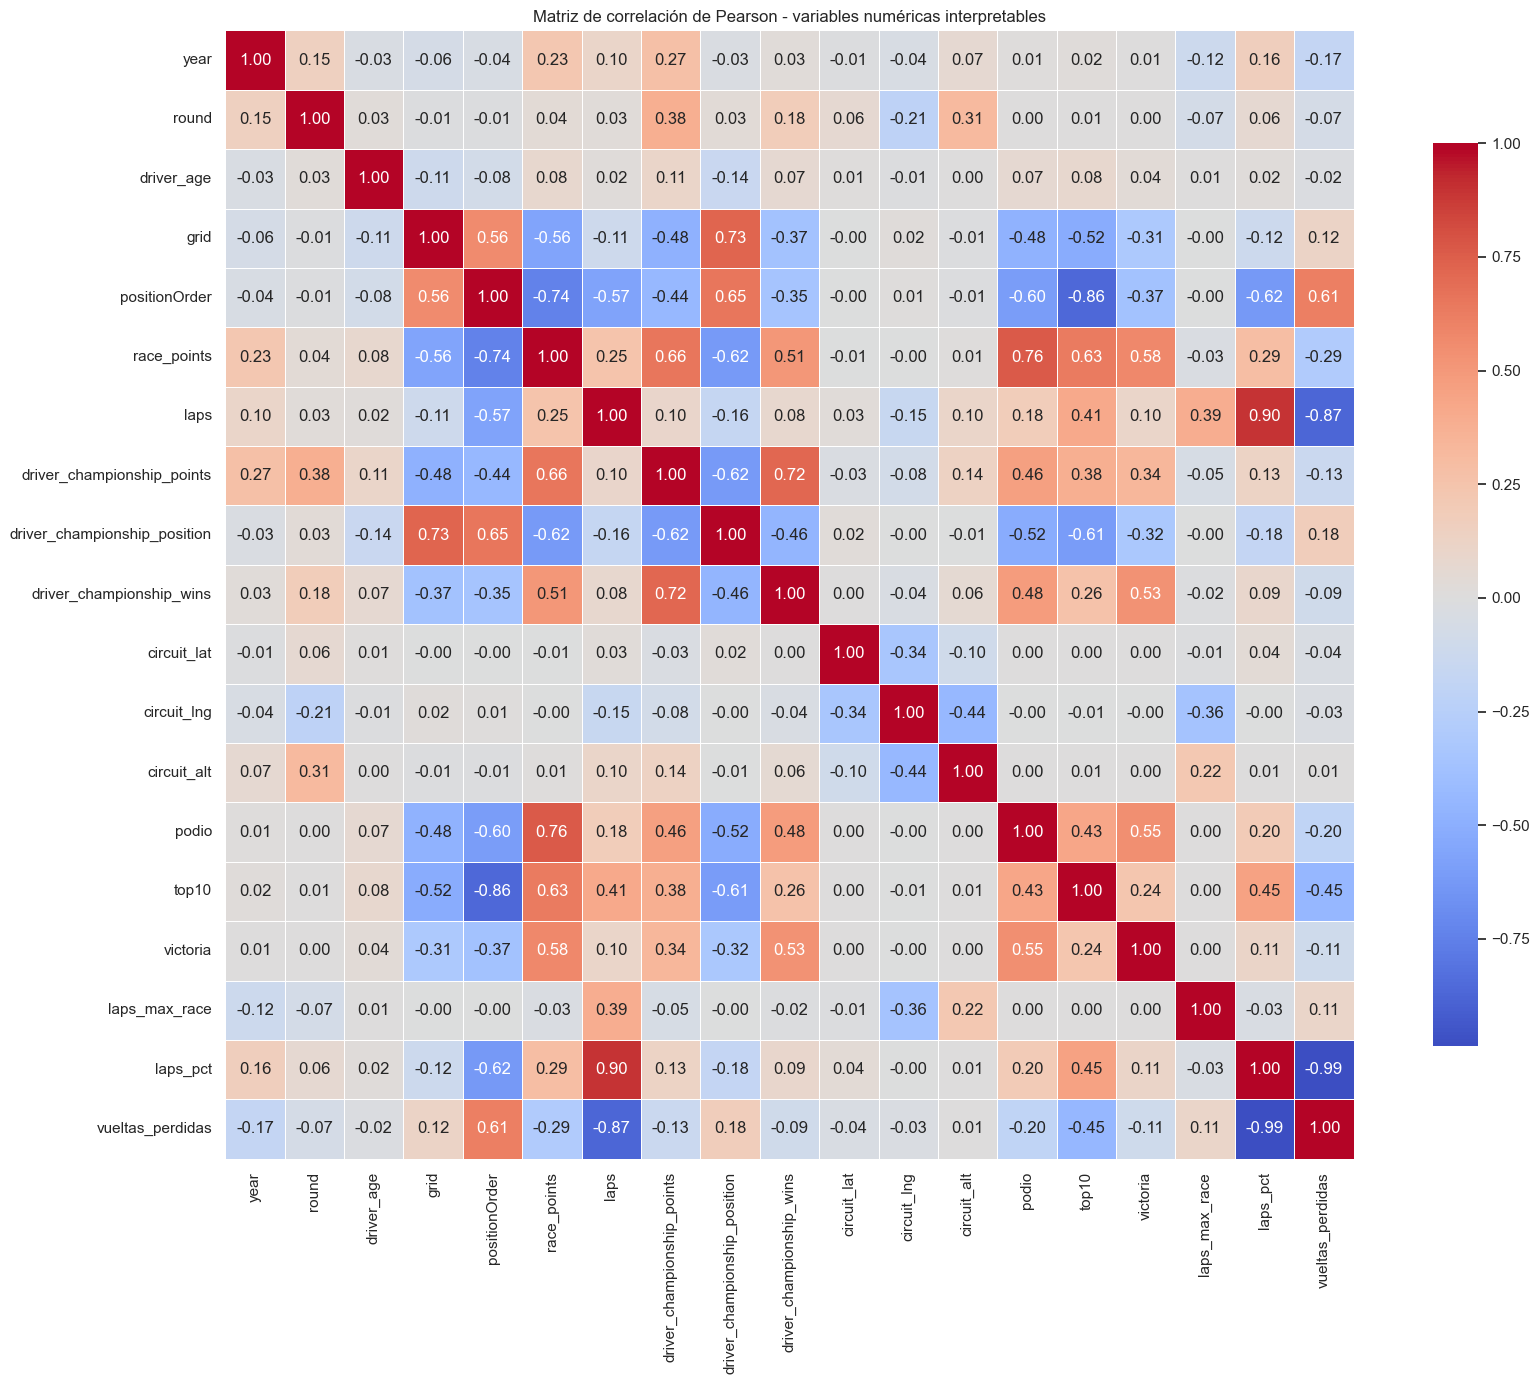

In [21]:
# ============================================================
# 9.6) HEATMAP DE CORRELACIÓN - TODAS LAS NUMÉRICAS INTERPRETABLES
# ============================================================

print("=" * 80)
print("9.6) HEATMAP DE CORRELACIÓN")
print("=" * 80)

df_corr = base_eda[variables_numericas_eda].copy()

for col in df_corr.columns:
    df_corr[col] = pd.to_numeric(df_corr[col], errors="coerce")

# Correlación de Pearson
matriz_correlacion = df_corr.corr(method="pearson")

display(matriz_correlacion.round(3))

matriz_correlacion.to_csv(DATA_PROCESSED / "formula1_matriz_correlacion_eda.csv")

plt.figure(figsize=(18, 14))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de correlación de Pearson - variables numéricas interpretables")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "eda_heatmap_todas_variables_numericas.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 9.7 Pairplot para evaluar linealidad

El pairplot permite mirar visualmente las relaciones entre pares de variables numéricas. Como la base tiene hasta 10.000 registros, se usa una muestra aleatoria para que el gráfico sea legible y no tarde demasiado.

Por defecto se grafican las variables candidatas para PCA, porque son las que realmente importan para evaluar estructura lineal. Si se quiere graficar absolutamente todas las variables numéricas interpretables, cambiar `USAR_SOLO_VARIABLES_PCA_EN_PAIRPLOT` a `False`.


Variables usadas en el pairplot:
['grid', 'positionOrder', 'laps_pct', 'driver_age', 'driver_championship_position', 'driver_championship_wins']

Cantidad de observaciones usadas en el pairplot:
1500


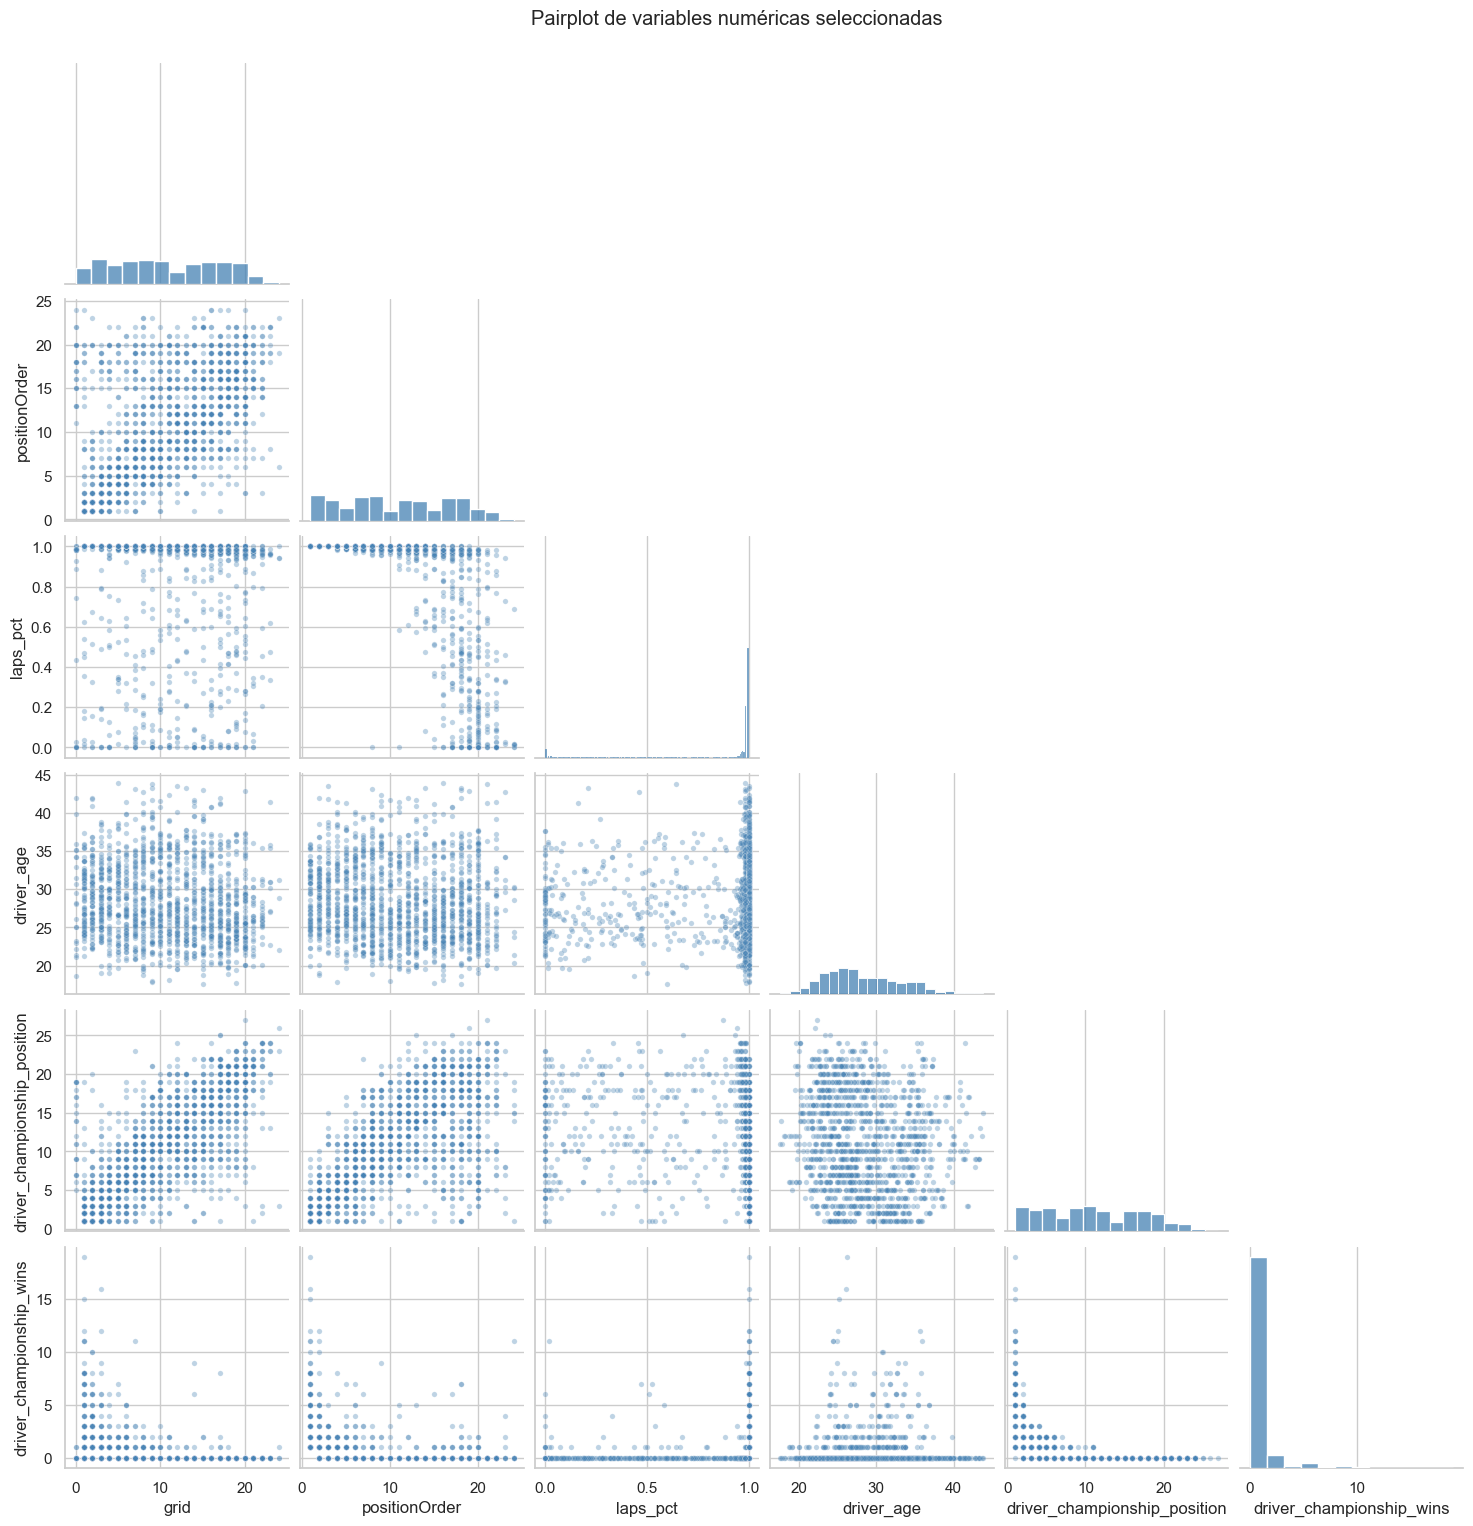

In [22]:
# ============================================================
# 9.7) PAIRPLOT
# ============================================================

USAR_SOLO_VARIABLES_PCA_EN_PAIRPLOT = True
TAMANIO_MUESTRA_PAIRPLOT = 1500

if USAR_SOLO_VARIABLES_PCA_EN_PAIRPLOT:
    variables_pairplot = variables_pca_candidatas.copy()
    nombre_pairplot = "eda_pairplot_variables_pca_candidatas.png"
else:
    variables_pairplot = variables_numericas_eda.copy()
    nombre_pairplot = "eda_pairplot_todas_variables_numericas.png"

# Evitar columnas con todos nulos o constantes.
variables_pairplot = [
    col for col in variables_pairplot
    if col in base_eda.columns and base_eda[col].nunique(dropna=True) > 1
]

df_pairplot = base_eda[variables_pairplot].copy()

for col in df_pairplot.columns:
    df_pairplot[col] = pd.to_numeric(df_pairplot[col], errors="coerce")

df_pairplot = df_pairplot.dropna()

if len(df_pairplot) > TAMANIO_MUESTRA_PAIRPLOT:
    df_pairplot = df_pairplot.sample(
        n=TAMANIO_MUESTRA_PAIRPLOT,
        random_state=42
    )

print("Variables usadas en el pairplot:")
print(variables_pairplot)

print("\nCantidad de observaciones usadas en el pairplot:")
print(len(df_pairplot))

if len(variables_pairplot) >= 2 and len(df_pairplot) > 0:
    pairplot = sns.pairplot(
        df_pairplot,
        diag_kind="hist",
        corner=True,
        plot_kws={"alpha": 0.35, "s": 15, "color": "steelblue"},
        diag_kws={"color": "steelblue"}
    )

    pairplot.fig.suptitle(
        "Pairplot de variables numéricas seleccionadas",
        y=1.02
    )

    pairplot.savefig(
        FIGURES_DIR / nombre_pairplot,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
else:
    print("No hay suficientes variables u observaciones para construir el pairplot.")


## 9.8 Cruces categóricos relevantes

Estos cruces permiten interpretar el dataset en términos deportivos. Por ejemplo, ayudan a ver cómo se relaciona el grupo de largada con el resultado final, o el estado final de la carrera con el resultado.


resultado_grupo,Fuera del top 10,Ganador,Podio,Top 10
largada_grupo,,,,
Fondo,75.97,0.17,1.13,22.73
Pit lane / no largó,85.71,0.00,0.00,14.29
Pole,11.95,50.94,27.46,9.64
Top 10,35.53,1.14,6.60,56.73
Top 5,18.61,10.46,31.86,39.06


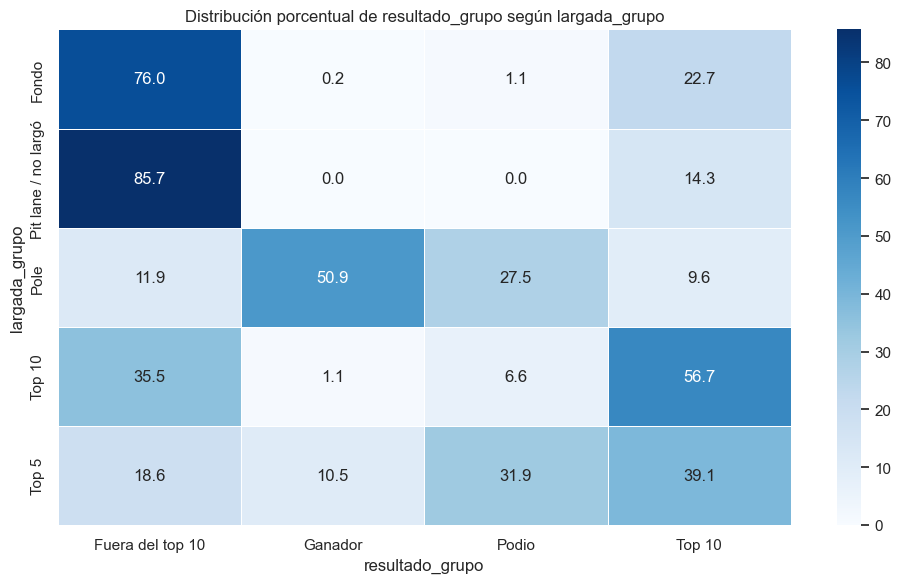

resultado_grupo,Fuera del top 10,Ganador,Podio,Top 10
status_grupo,,,,
Abandono mecánico,98.52,0.00,0.00,1.48
Clasificado / terminó,38.52,6.22,12.38,42.88
Incidente / abandono,99.10,0.00,0.00,0.90
Otro,99.33,0.00,0.00,0.67


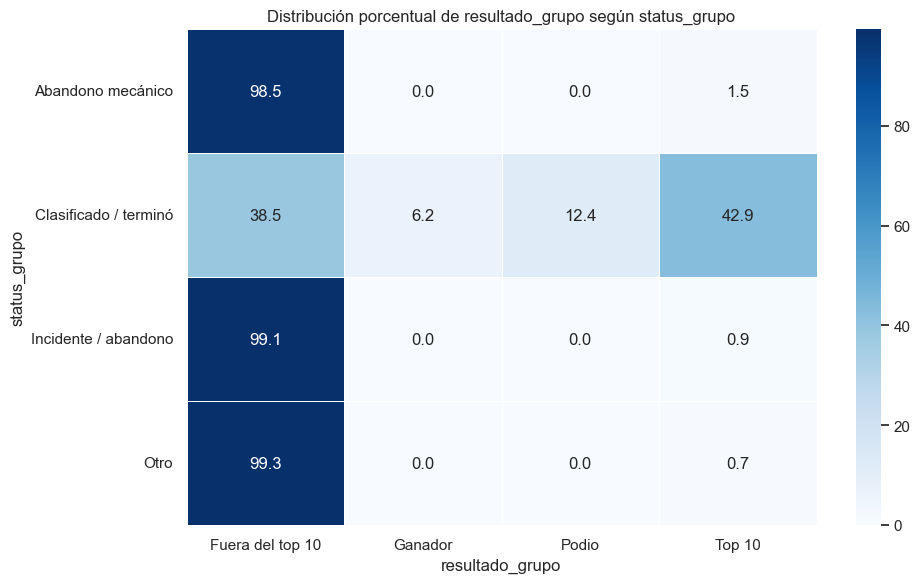

In [23]:
# ============================================================
# 9.8) CRUCES CATEGÓRICOS
# ============================================================

def tabla_cruzada_porcentual(df, fila, columna, nombre_archivo):
    tabla = pd.crosstab(
        df[fila],
        df[columna],
        normalize="index"
    ) * 100

    display(tabla.round(2))

    tabla.to_csv(DATA_PROCESSED / nombre_archivo)

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        tabla,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        linewidths=0.5
    )
    plt.title(f"Distribución porcentual de {columna} según {fila}")
    plt.xlabel(columna)
    plt.ylabel(fila)
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / nombre_archivo.replace(".csv", ".png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

if "largada_grupo" in base_eda.columns and "resultado_grupo" in base_eda.columns:
    tabla_cruzada_porcentual(
        base_eda,
        fila="largada_grupo",
        columna="resultado_grupo",
        nombre_archivo="formula1_cruce_largada_resultado_eda.csv"
    )

if "status_grupo" in base_eda.columns and "resultado_grupo" in base_eda.columns:
    tabla_cruzada_porcentual(
        base_eda,
        fila="status_grupo",
        columna="resultado_grupo",
        nombre_archivo="formula1_cruce_status_resultado_eda.csv"
    )


## 9.9 Cierre del EDA

A partir del EDA se deja preparada una lista inicial de variables numéricas candidatas para PCA. En la próxima etapa conviene:

1. revisar nulos en esas variables;
2. definir si se imputan o eliminan filas;
3. estandarizar la matriz;
4. guardar la matriz final para PCA;
5. aplicar PCA y luego clustering sobre los scores o sobre una matriz estandarizada.


In [24]:
# ============================================================
# 9.9) GUARDADO DE VARIABLES CANDIDATAS PARA PCA
# ============================================================

df_variables_pca = pd.DataFrame({
    "variable": variables_pca_candidatas
})

df_variables_pca.to_csv(
    DATA_PROCESSED / "formula1_variables_pca_candidatas.csv",
    index=False
)

print("Variables candidatas para PCA guardadas en:")
print(DATA_PROCESSED / "formula1_variables_pca_candidatas.csv")

display(df_variables_pca)


Variables candidatas para PCA guardadas en:
/Users/santinoalmiron/Documents/Facultad/3º año/1º cuatrimestre/Analisis Multivariado/Analisis-multivariado/data/processed/formula1_variables_pca_candidatas.csv


,variable
0,grid
1,positionOrder
2,laps_pct
3,driver_age
4,driver_championship_position
5,driver_championship_wins
